# Startup success prediction model

Aim of this notebook is to create a startup success prediction model based on data publicy available on Kaggle: https://www.kaggle.com/datasets/arindam235/startup-investments-crunchbase/data

We have already undergone a separate data cleaning of the dataset according to the needs of visualization of the overall project, as describe in the notebook "01_Data_cleaning" included in the same repository.

This prediction model is part of a wider contribution to an investment project of an Italian investment fund focused on start-ups, whose aim is to open a new office in Spain.

Considering the wider project, we'll take into account the geographic relevance of the data available to try tailoring the model to the specific client's needs.

In [ ]:
# Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle as pck

from pathlib import Path
import os

from scipy.stats import chi2_contingency, pointbiserialr

from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import TargetEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit,GridSearchCV
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, roc_auc_score, roc_curve
from sklearn.inspection import permutation_importance
from sklearn.utils.class_weight import compute_class_weight

from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import GradientBoostingClassifier

os.environ["KERAS_BACKEND"] = "jax"
import keras

In [254]:
# Setting dataset path

repo_root = Path.cwd().parent
file_name = "startups_funding_global.csv"
file_path = repo_root / "Data" / "01_Cleaned" / file_name

# Importing the dataset

df = pd.read_csv(file_path)
df.head()

,name,country_code,state_code,region,city,market_category,market,founded_at,funding_total_usd,funding_rounds,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,#waywire,USA,NY,New York City,New York,Entertainment & Media,News,2012-06-01,1750000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,&TV Communications,USA,CA,Los Angeles,Los Angeles,Entertainment & Media,Games,NaN,4000000.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,'Rock' Your Paper,EST,NaN,Tallinn,Tallinn,Entertainment & Media,Publishing,2012-10-26,40000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,(In)Touch Network,GBR,NaN,London,London,Hardware & Semiconductors,Electronics,2011-04-01,1500000.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-R- Ranch and Mine,USA,TX,Dallas,Fort Worth,Travel & Hospitality,Tourism,2014-01-01,60000.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Statistics and features selection

We first describe the dataset and perform a basic EDA.

Aim is to understand the most relevant variables to include in the model, identifying outliers and potential bias in the model.

In [505]:
# Basic info about the dataset

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 40845 entries, 0 to 40844
Data columns (total 35 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  40845 non-null  str           
 1   country_code          37033 non-null  str           
 2   state_code            25580 non-null  str           
 3   region                37033 non-null  str           
 4   city                  36347 non-null  str           
 5   market_category       38340 non-null  str           
 6   market                38340 non-null  str           
 7   founded_at            32151 non-null  datetime64[us]
 8   funding_total_usd     40845 non-null  float64       
 9   funding_rounds        40845 non-null  float64       
 10  first_funding_at      40845 non-null  str           
 11  last_funding_at       40845 non-null  str           
 12  status                39740 non-null  str           
 13  seed                  13802

### Categorical variables

In [506]:
# Description of categorical variables

df.describe(exclude="number").T

,count,unique,top,freq,mean,min,25%,50%,75%,max
name,40845,40845,#waywire,1,NaN,NaN,NaN,NaN,NaN,NaN
country_code,37033,110,USA,24439,NaN,NaN,NaN,NaN,NaN,NaN
state_code,25580,61,CA,8597,NaN,NaN,NaN,NaN,NaN,NaN
region,37033,1031,SF Bay Area,5977,NaN,NaN,NaN,NaN,NaN,NaN
city,36347,3585,San Francisco,2263,NaN,NaN,NaN,NaN,NaN,NaN
market_category,38340,19,Software & SaaS,7721,NaN,NaN,NaN,NaN,NaN,NaN
market,38340,735,Software,4049,NaN,NaN,NaN,NaN,NaN,NaN
founded_at,32151,NaN,NaN,NaN,2007-02-14 09:09:14.595502,1636-09-08 00:00:00,2005-01-01 00:00:00,2009-08-01 00:00:00,2012-01-01 00:00:00,2014-12-13 00:00:00
first_funding_at,40845,3651,2012-01-01,349,NaN,NaN,NaN,NaN,NaN,NaN
last_funding_at,40845,3356,2014-01-01,274,NaN,NaN,NaN,NaN,NaN,NaN


In [507]:
# Country code description

df["country_code"].value_counts(normalize=True).sort_values(ascending=False)

country_code
USA    0.659925
GBR    0.061621
CAN    0.031431
CHN    0.026652
FRA    0.020684
         ...   
CIV    0.000027
SOM    0.000027
MKD    0.000027
SYC    0.000027
MAF    0.000027
Name: proportion, Length: 110, dtype: float64

In [508]:
# State code description including corresponding country code

df[["country_code", "state_code"]].value_counts(normalize=True).sort_values(ascending=False)

country_code  state_code
USA           CA            0.336083
              NY            0.097263
              MA            0.070758
              TX            0.048124
              WA            0.034597
                              ...   
              SD            0.000352
              WY            0.000352
CAN           NB            0.000274
              SK            0.000078
              PE            0.000078
Name: proportion, Length: 61, dtype: float64

In [509]:
# Region description including corresponding country code

df[["country_code", "region"]].value_counts(normalize=True).sort_values(ascending=False)

country_code  region         
USA           SF Bay Area        0.161397
              New York City      0.060055
              Boston             0.045770
GBR           London             0.036535
USA           Los Angeles        0.030702
                                   ...   
JPN           Fukuoka            0.000027
FRA           Annecy             0.000027
MLT           MLT - Other        0.000027
IND           Jodhpur            0.000027
GBR           Buckinghamshire    0.000027
Name: proportion, Length: 1038, dtype: float64

The dataset is heavily skewed toward US startups, which represent over 65% of the total entries.

State code is also only applying to start-ups in the US or Canada.
On the other hand, region applies internationally.

We believe that taking into account the geographical information wouldn't make sense if the specific application case is mainly focused on start-ups located in other countries.

For this reason, we decide to exclude the variables: country_code, state_code, region, city from the model.

In [510]:
# Description of market_category

df["market_category"].value_counts(normalize=True).sort_values(ascending=False)

market_category
Software & SaaS              0.201382
E-Commerce & Retail          0.097235
Other                        0.096688
Biotechnology                0.092306
Entertainment & Media        0.073657
Healthcare                   0.072327
Mobile                       0.052739
Hardware & Semiconductors    0.047470
Social & Communication       0.046688
Advertising & Marketing      0.040949
Finance & FinTech            0.032499
Clean Tech & Energy          0.031273
Analytics & AI               0.028456
Manufacturing & Logistics    0.026943
Education                    0.020892
Security                     0.015232
Travel & Hospitality         0.011685
Real Estate                  0.008425
Energy                       0.003156
Name: proportion, dtype: float64

In [511]:
# Description of market

df["market"].value_counts(normalize=True).sort_values(ascending=False)

market
Software                0.105608
Biotechnology           0.091784
Mobile                  0.044523
E-Commerce              0.038054
Curated Web             0.034820
                          ...   
Group SMS               0.000026
Service Industries      0.000026
Wind                    0.000026
New Technologies        0.000026
Clean Technology IT     0.000026
Name: proportion, Length: 735, dtype: float64

Market_category is a variable previosuly created to reduce the number of unique markets, see notebook "01_Data_cleaning" for more details.

We keep only the market_category variable for the sake of the prediction to reduce the specificity, even if we lose some detail considering the macro category "other".

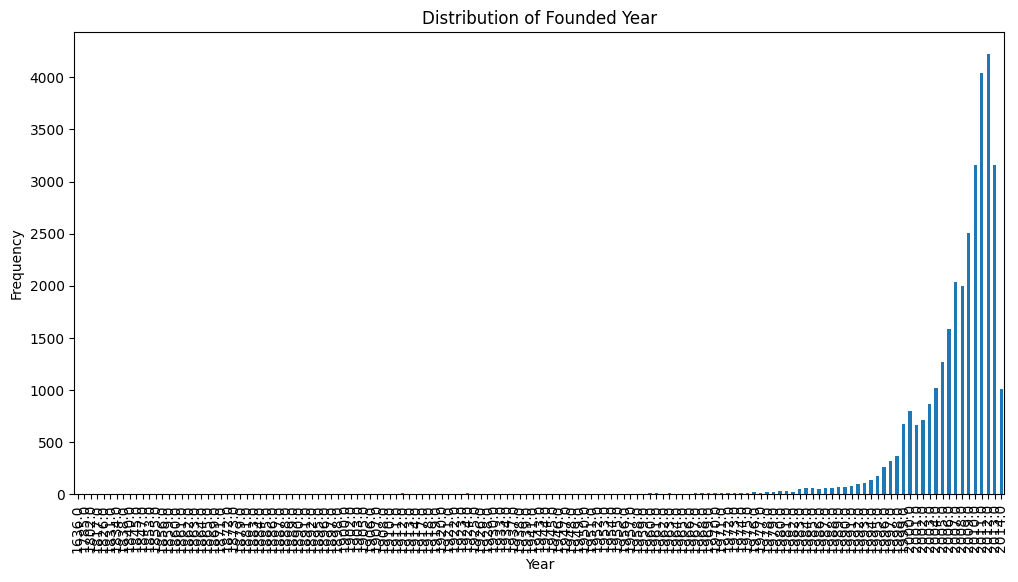

In [512]:
# Visualization of the distribution of the founded_at, grouped by year

df["founded_at"] = pd.to_datetime(df["founded_at"], errors="coerce")
df["founded_year"] = df["founded_at"].dt.year

df["founded_year"].value_counts().sort_index().plot(kind="bar", figsize=(12, 6))
plt.title("Distribution of Founded Year")
plt.xlabel("Year")
plt.ylabel("Frequency")
plt.show()


In [513]:
df['founded_year'].describe()

count    32151.000000
mean      2006.927498
std         10.058396
min       1636.000000
25%       2005.000000
50%       2009.000000
75%       2012.000000
max       2014.000000
Name: founded_year, dtype: float64

The distribution of the founded date grouped by year shows both the presence of some outliers (1636) as well as a skewed distribution towards the years 2005-20014 (75% of the observation).

We decide on one hand not to use this variable in our prediction, since it's unlikely we'll predict the success of a start-up founded more than 10 years ago compared to current date (2026).

On the other hand, we filter for only the start-ups in the period 2000-2014, since prior to that we could argue the financing methods and pattern we are interested to observe would be relevant to a modern start-up we aim to predict the success for.

In [514]:
# Filter for 2000-2014

df_filtered = df[(df['founded_year'] >= 2000)]

The other date columns can be summarised with a numeric value representing the funding cycle of the start-up, expressed in months.

We apply the calculation and discard the original first_funding_at and last_funding_at columns in the prediction model.

In [515]:
# Calculating the funding cycle duration in months

df_filtered['funding_cycle_months'] = (pd.to_datetime(df_filtered['last_funding_at'], errors='coerce') - pd.to_datetime(df_filtered['founded_at'], errors='coerce')).dt.days / 30

# Filtering out negative funding cycle durations

df_filtered = df_filtered[df_filtered['funding_cycle_months'] >= 0]

In [516]:
# Description of status

df_filtered["status"].value_counts(normalize=True).sort_values(ascending=False)

status
operating    0.871127
acquired     0.076563
closed       0.052310
Name: proportion, dtype: float64

The majority of the listed start-ups are still showing as operating, less than 7% is aquired and around 5% is closed.

This is a potential bias to be considered if we were to consider this variable as a target prediction.

### Numerical variables

In [517]:
# Description of numerical variables

df_filtered.describe(include="number").T

,count,mean,std,min,25%,50%,75%,max
funding_total_usd,27989.0,2.140287e+07,9.134806e+07,14.0,330000.00,2000000.0,1.350000e+07,5.700000e+09
funding_rounds,27989.0,1.972418e+00,1.470431e+00,1.0,1.00,1.0,2.000000e+00,1.800000e+01
seed,10925.0,8.122111e+05,1.586235e+06,14.0,95851.00,400000.0,1.077500e+06,1.000000e+08
venture,15429.0,1.755544e+07,4.574109e+07,291.0,1700000.00,5716641.0,1.725000e+07,2.351000e+09
equity_crowdfunding,436.0,5.497275e+05,1.779689e+06,80.0,20000.00,95887.5,3.985728e+05,2.500000e+07
undisclosed,537.0,4.114841e+06,1.367117e+07,344.0,227287.00,750000.0,3.125000e+06,2.508000e+08
convertible_note,455.0,1.229594e+06,2.724358e+06,30.0,127549.00,460714.0,1.333692e+06,3.897941e+07
debt_financing,2910.0,1.065400e+07,7.796734e+07,100.0,340000.00,1100000.0,3.801989e+06,2.400000e+09
angel,2641.0,9.719358e+05,1.927285e+06,23.0,200000.00,500000.0,1.000000e+06,4.392386e+07
grant,691.0,3.806277e+06,2.198532e+07,300.0,50000.00,235536.0,1.400000e+06,4.000000e+08


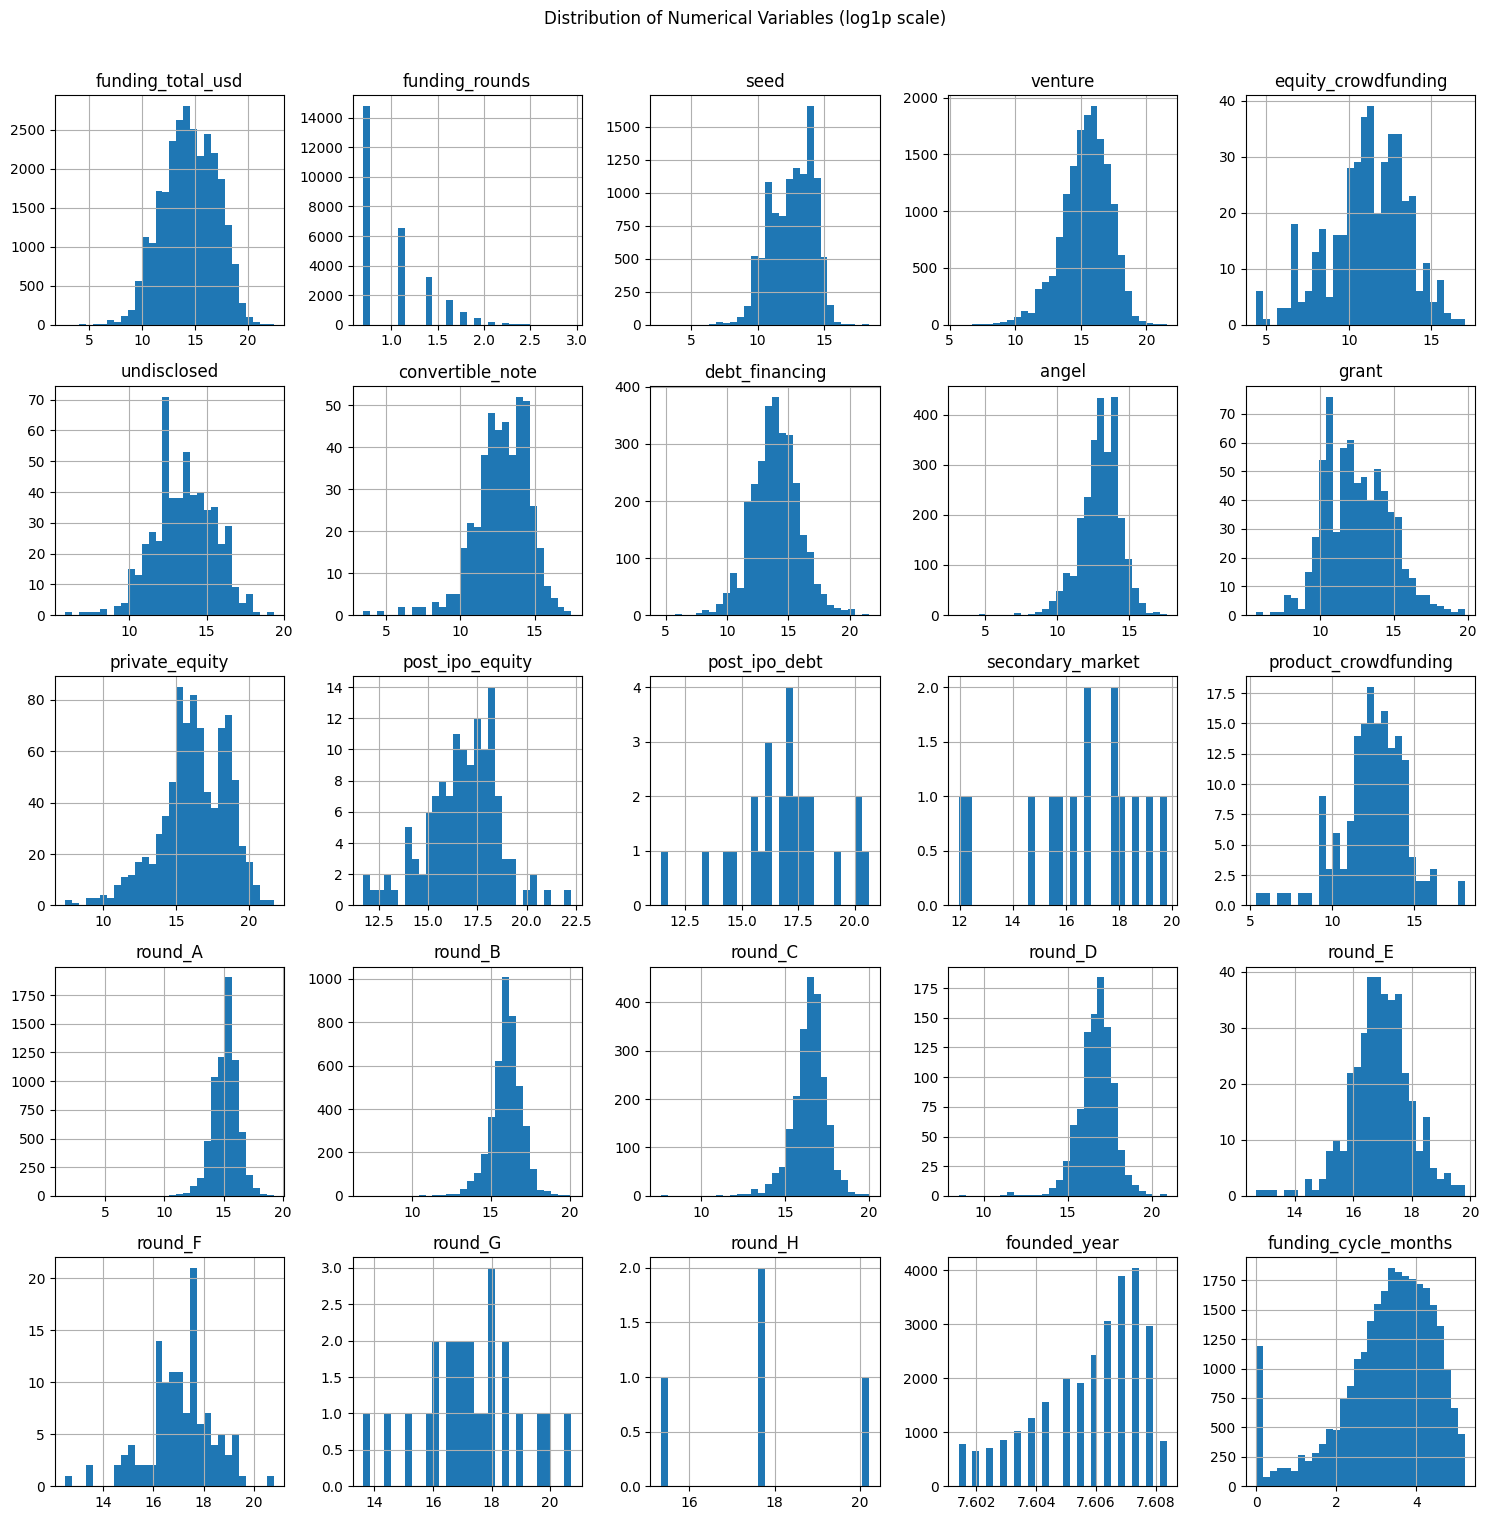

In [518]:
# Visualization of the numerical variables distribution

numerical_cols = df_filtered.select_dtypes(include=np.number).columns
df_filtered[numerical_cols].apply(np.log1p).hist(bins=30, figsize=(15, 15))
plt.suptitle("Distribution of Numerical Variables (log1p scale)", y=1.01)
plt.tight_layout()
plt.show()

The numerical variables describe, for each start-up, the financing profile and size.

A general observation is the presence of outliers, which are likely due to an extremely high financing in some specific, high successful start-up.

The overall preferred finaning method is venture and seed, on which over ~50% and ~30% of the start-ups registered have attracted.

The least used financing methods are secondary market and instruments like post-IPO debt.

### Features engineering

In a scenario of a classification, we decide to opt for the following strategy in terms of variables selection and feature engineering:

General features

- "avg. funding per round"
- "funding diversity", counting distinct financing types
- "funding intensity", avg funding per month
- "rounds per year" feature
- "Has early stage" feature, boolean for seed or angel presence
- "Has late stage" feature, boolean for round_D to round_H

Funding type composition

- Institutional funding share: venture + private equity to total funding
- debt_vs_equity ratio
- post_ipo_presence

Drop
- geographical features
- founded year

In [519]:
# Calculating the avg. funding amount per round

df_filtered['funding_avg_per_round'] = df_filtered['funding_total_usd'] / df_filtered['funding_rounds']

In [520]:
# Calculating the funding diversity index (number of unique funding types)

df_filtered['funding_diversity'] = df_filtered[['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 'debt_financing', 'angel', 'grant',
                                                'private_equity','post_ipo_equity','post_ipo_debt','secondary_market','product_crowdfunding']].nunique(axis=1)

In [521]:
# Calculating funding intensity

df_filtered['funding_intensity'] = df_filtered['funding_total_usd'] / df_filtered['funding_cycle_months']

In [522]:
# Calculatng rounds per year

df_filtered['rounds_per_year'] = df_filtered['funding_rounds'] / (df_filtered['funding_cycle_months'] / 12)

In [523]:
# Calculating "has early stage funding" variable

df_filtered['has_early_stage'] = df_filtered[['seed', 'angel']].any(axis=1).astype(int)

In [524]:
# Has late stage funding variable

df_filtered['has_late_stage'] = df_filtered[['round_D', 'round_E', 'round_F', 'round_G', 'round_H']].any(axis=1).astype(int)

In [525]:
# Institutional funding share

df_filtered['institutional_share'] = df_filtered[['venture', 'private_equity']].sum(axis=1) / df_filtered['funding_total_usd']

In [526]:
# debt vs equity ratio

df_filtered['debt_equity_ratio'] = df_filtered[['debt_financing','convertible_note']].sum(axis=1) / (df_filtered[['venture', 'angel','private_equity']].sum(axis=1) + 1e-6)

In [527]:
# Post-ipo presence variable

df_filtered['post_ipo_presence'] = df_filtered[['post_ipo_equity', 'post_ipo_debt']].any(axis=1).astype(int)

### Conclusions

In [ ]:
# Selecting variables from previous steps

selected_vars = ['market_category', 'funding_total_usd', 'funding_rounds','status','seed','venture','equity_crowdfunding', 'undisclosed', 
                 'convertible_note', 'debt_financing', 'angel', 'grant','private_equity','post_ipo_equity','post_ipo_debt','secondary_market',
                 'product_crowdfunding','round_A','round_B','round_C','round_D','round_E','round_F','round_G','round_H','funding_cycle_months',
                 'funding_avg_per_round','funding_diversity','funding_intensity','rounds_per_year','has_early_stage','has_late_stage',
                 'institutional_share','debt_equity_ratio','post_ipo_presence']

In [529]:
# Dropping unwanted variables

df_filtered = df_filtered[selected_vars]

# Filling nan in market_category with 'Unknown'

df_filtered['market_category'] = df_filtered['market_category'].fillna('Unknown')

# Replacing inf/-inf and filling nan in numerical variables with 0

numerical_cols = df_filtered.select_dtypes(include=np.number).columns
df_filtered[numerical_cols] = df_filtered[numerical_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

# Dropping nan in status

df_filtered = df_filtered.dropna(subset=['status'])
df_filtered = df_filtered.reset_index(drop=True)


## Binary classification: Start-ups acquisition or closure

### Variables fine tuning

We initially operate on refining the dataset and the target Y variable "Status".

In [700]:
# Filtering for closed and operating startups

df_bclass = df_filtered[df_filtered['status'].isin(['closed', 'acquired'])].copy()

In [701]:
# Turning the target variable into boolean (True for acquired, False for closed)

df_bclass['status'] = df_bclass['status'].map({'closed': False, 'acquired': True})

In [702]:
# Dscribing the new dataset for the prediction model

df_bclass.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
market_category,3523,20,Software & SaaS,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funding_total_usd,3523.0,NaN,NaN,NaN,25821718.659949,120421444.313187,1000.0,685675.0,5500000.0,24370000.0,5700000000.0
funding_rounds,3523.0,NaN,NaN,NaN,2.01107,1.356266,1.0,1.0,2.0,3.0,10.0
status,3523,2,True,2093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seed,3523.0,NaN,NaN,NaN,230452.336645,774148.553688,0.0,0.0,0.0,50000.0,21000000.0
venture,3523.0,NaN,NaN,NaN,11704293.537326,28021013.741197,0.0,0.0,3000000.0,13000000.0,775000000.0
equity_crowdfunding,3523.0,NaN,NaN,NaN,2256.599489,101093.622496,0.0,0.0,0.0,0.0,5500000.0
undisclosed,3523.0,NaN,NaN,NaN,39541.518024,746260.101469,0.0,0.0,0.0,0.0,30000000.0
convertible_note,3523.0,NaN,NaN,NaN,10495.991768,251867.206217,0.0,0.0,0.0,0.0,13520145.0
debt_financing,3523.0,NaN,NaN,NaN,1082558.509793,17520406.195418,0.0,0.0,0.0,0.0,721644319.0


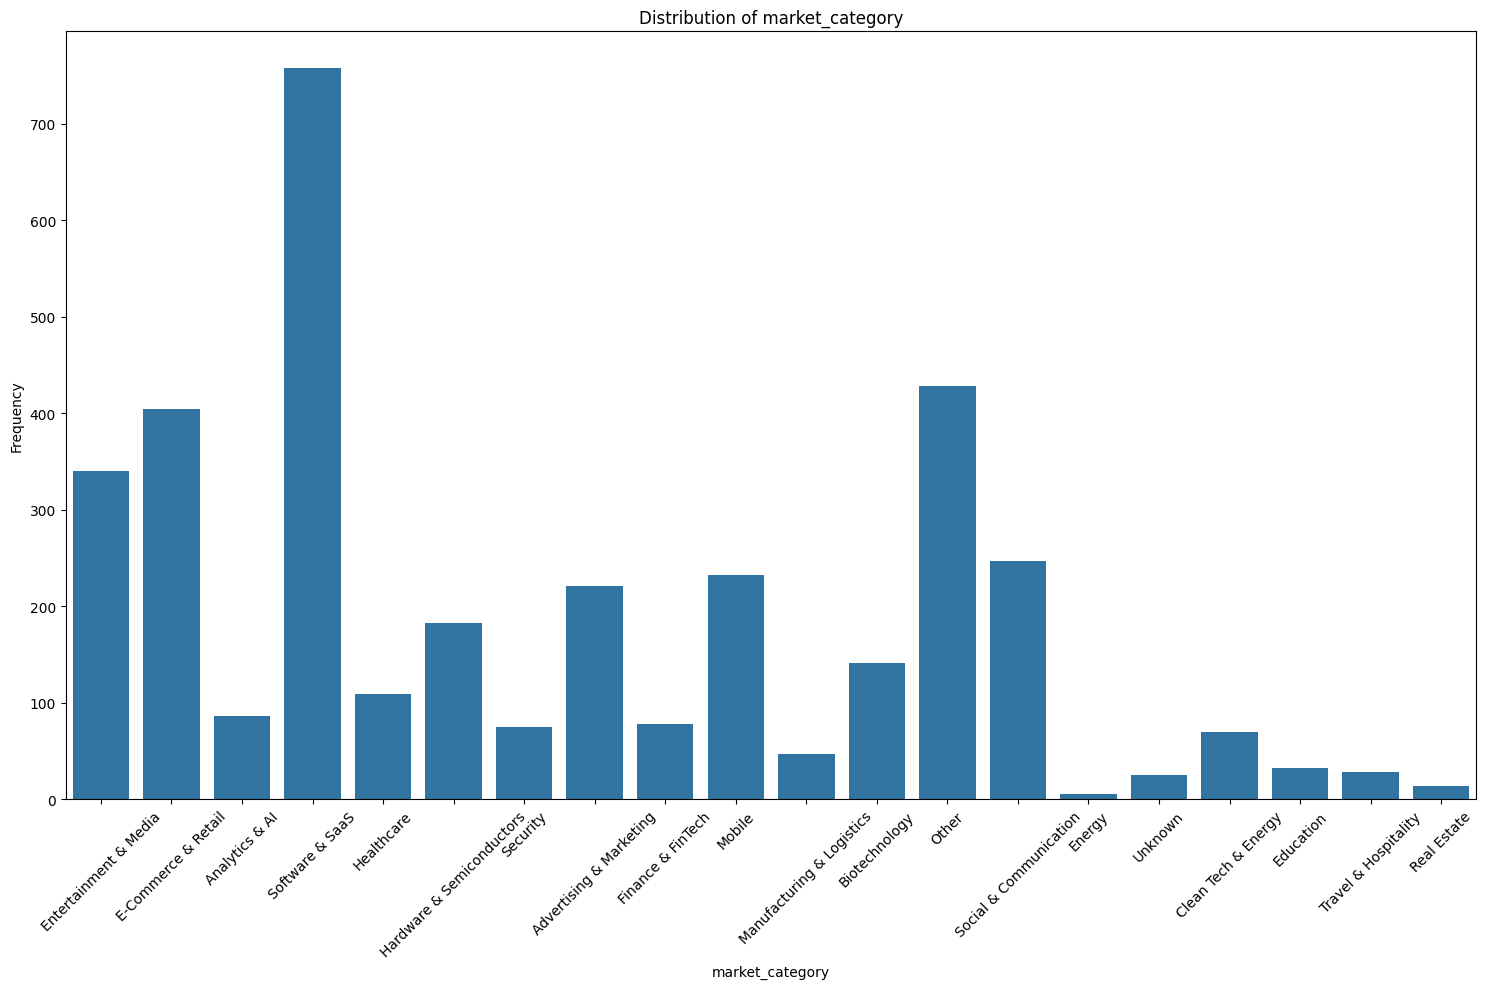

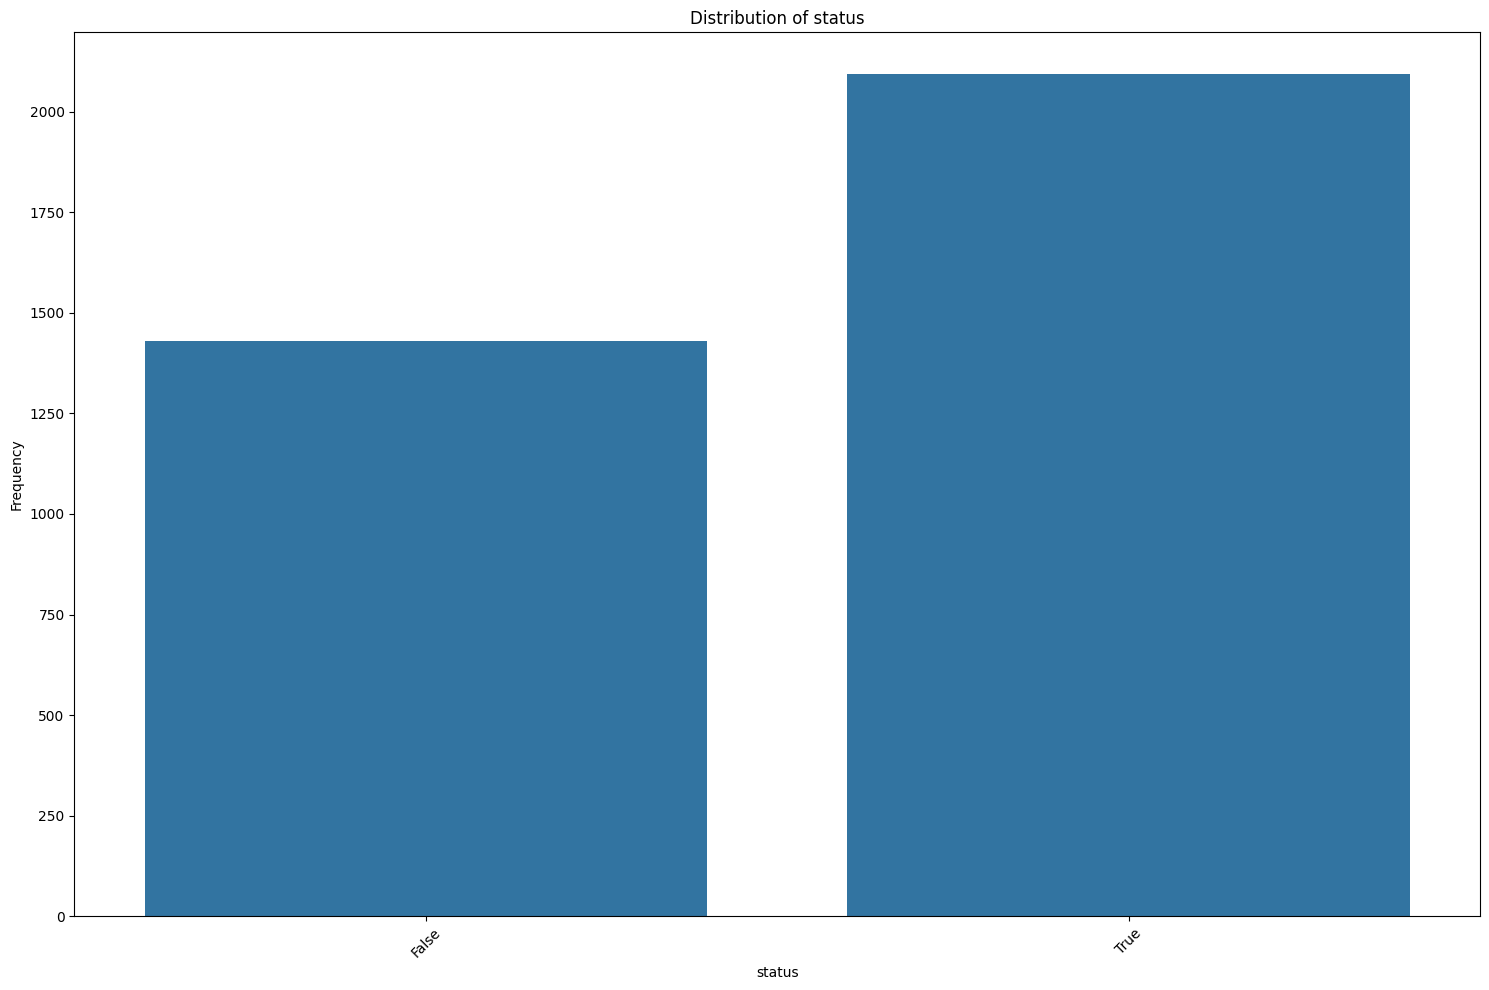

In [703]:
# Visualization of categorical variables distribution

categorical_cols = df_bclass[['market_category','status']]
for col in categorical_cols:
    plt.figure(figsize=(15, 10))
    sns.countplot(data=df_bclass, x=col)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


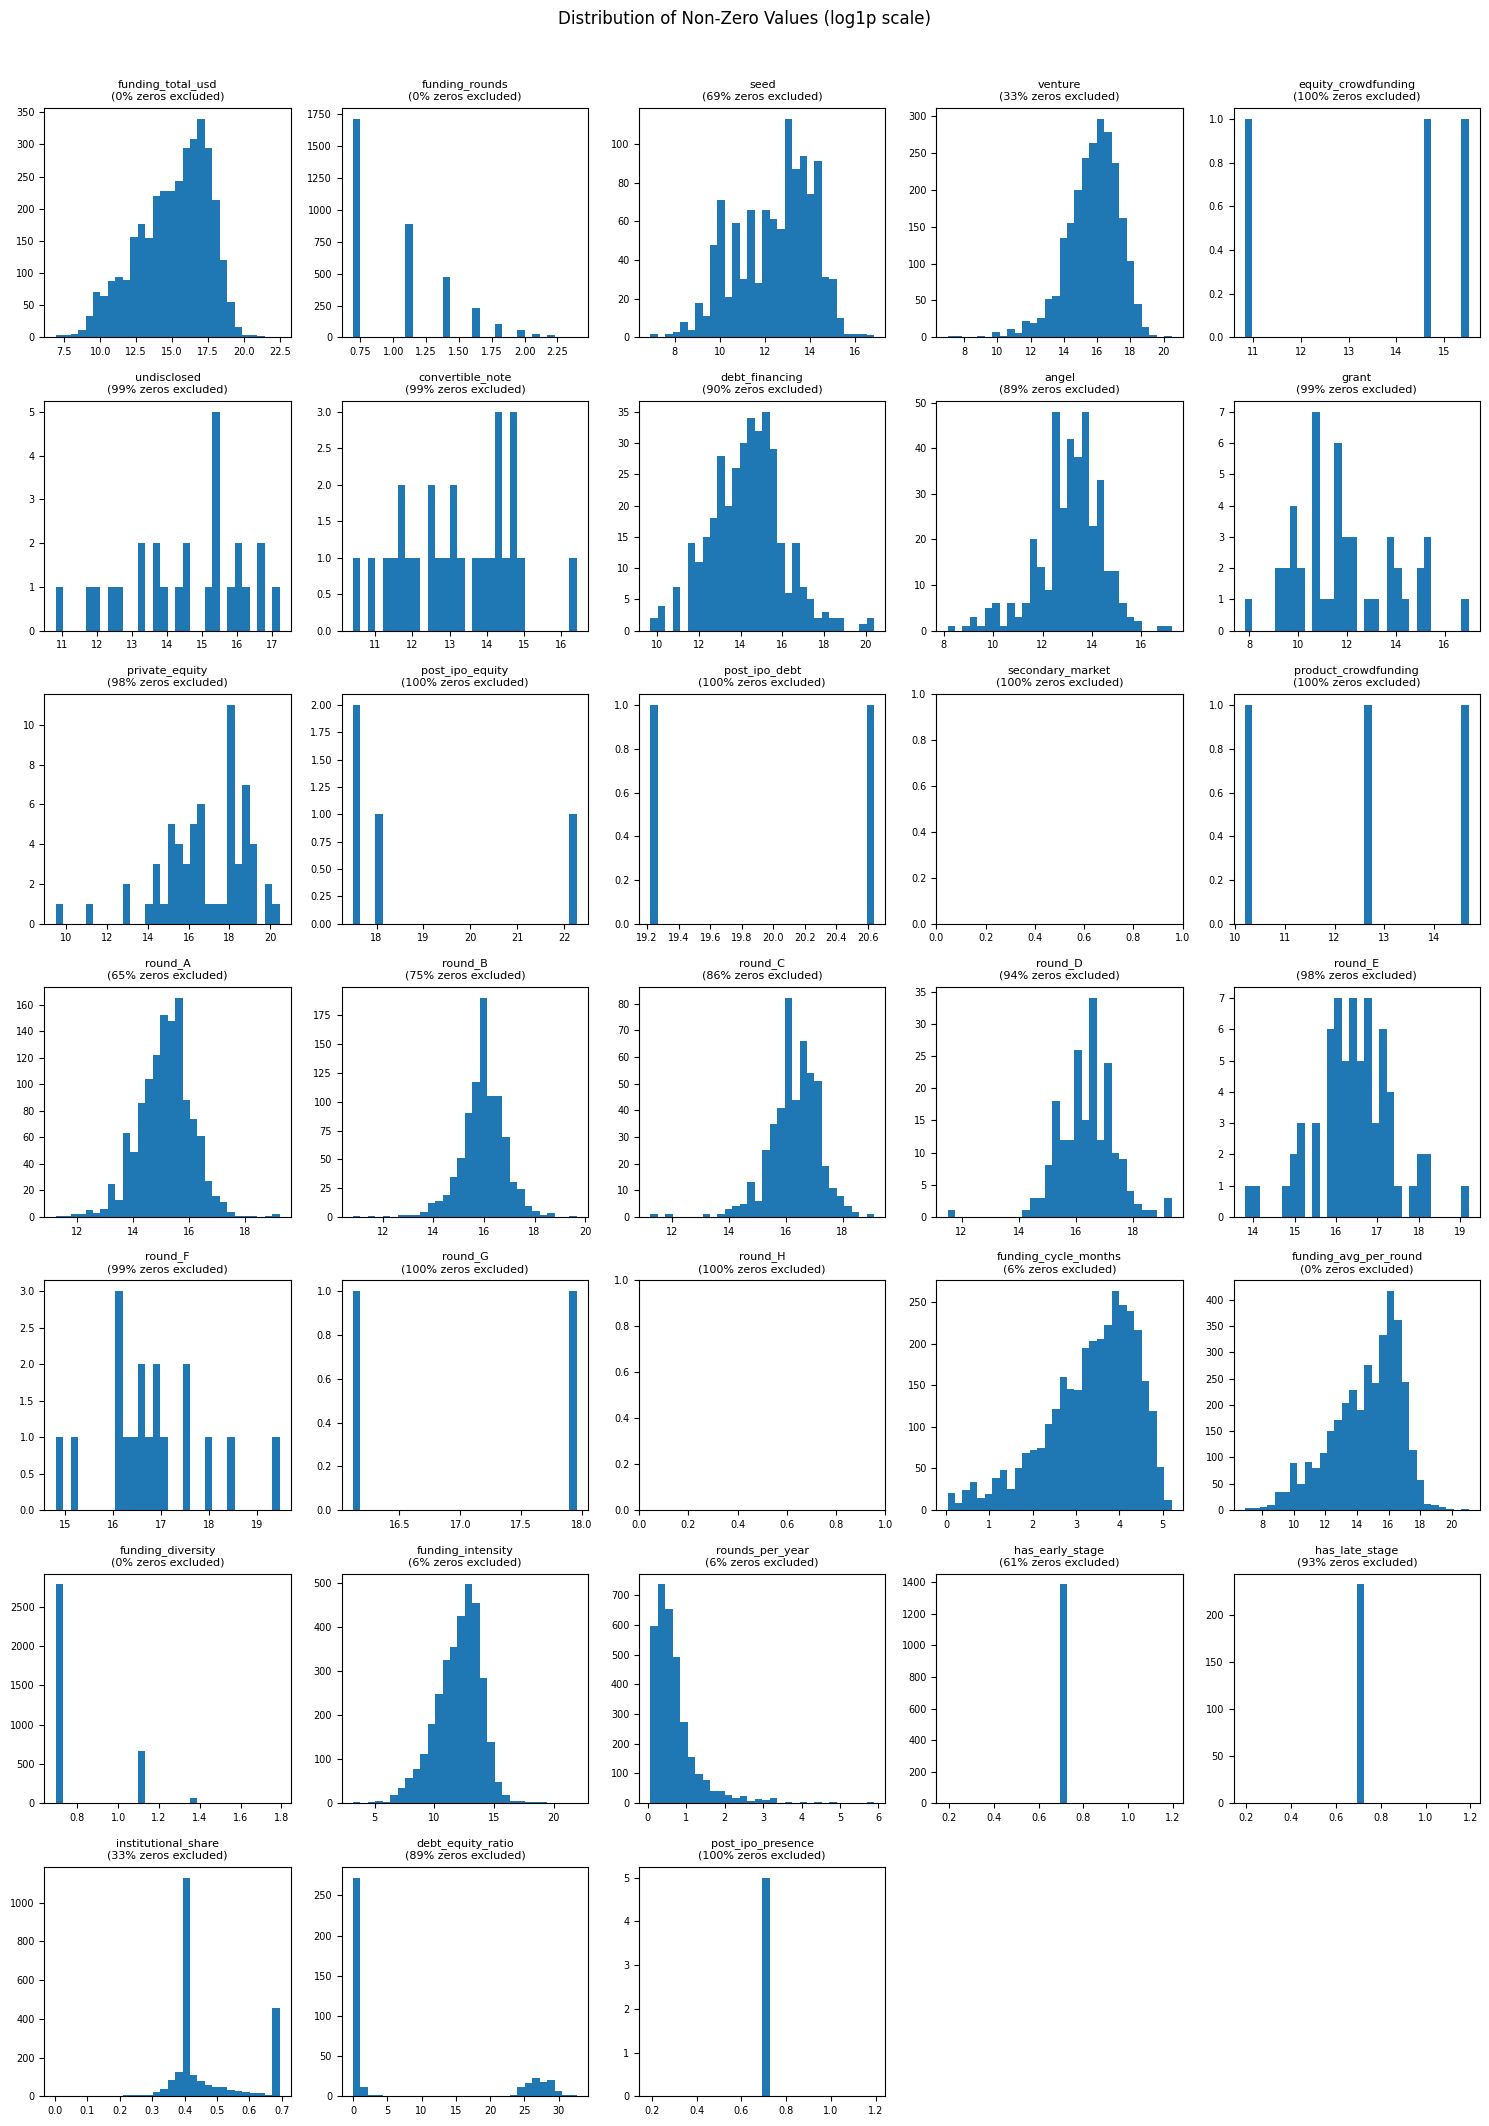

In [704]:
# Visualization of numerical variables distribution

numerical_cols = df_bclass.select_dtypes(include=np.number).columns
n = len(numerical_cols)
ncols = 5
nrows = (n + ncols - 1) // ncols

fig, axes = plt.subplots(nrows, ncols, figsize=(15, nrows * 3))
axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    data = df_bclass[col]
    non_zero = data[(data > 0) & np.isfinite(data)]
    zero_pct = (data == 0).mean() * 100
    
    if len(non_zero) > 1:
        axes[i].hist(np.log1p(non_zero), bins=30)
    axes[i].set_title(f"{col}\n({zero_pct:.0f}% zeros excluded)", fontsize=8)
    axes[i].tick_params(labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distribution of Non-Zero Values (log1p scale)", y=1.01)
plt.tight_layout()
plt.show()


The dataset is skewed towards adquired start-ups, which represent almost 60% of the observation.
This is an importance bias to consider when evaluating the models performance.

The other variables are coeherent with the distributions seen in the overall dataset.

We decide to opt for a target encoding strategy on the variable "market category" for this classification task.

Reason being that we want to capture the historical acquisition rate per sector.

In [705]:
# Splitting the dataset into features and target

x = df_bclass.drop(columns='status')
y = df_bclass['status']

In [706]:
# Splitting a train and test dataset (80% train, 20% test)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [707]:
# Encoding "Market" with target encoding, handling unknown categories in test set

encoder = TargetEncoder(target_type='binary', smooth='auto', random_state=42)
encoder = encoder.fit(x_train[['market_category']], y_train)

x_train['market_category'] = encoder.transform(
    x_train[['market_category']]
).ravel()

x_test['market_category'] = encoder.transform(
    x_test[['market_category']]
).ravel()

### Decision tree

In [708]:
# Model training

model = DecisionTreeClassifier(random_state=42)

decision_tree = GridSearchCV(estimator=model, param_grid={
    'max_depth': range(1,10),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}, cv=5, scoring='roc_auc').fit(x_train, y_train)

In [709]:
# Model evaluation

y_pred = decision_tree.predict(x_test)
y_proba = decision_tree.predict_proba(x_test)[:, 1]

In [710]:
# Model performance metrics

accuracy_tree = accuracy_score(y_test, y_pred)
auc_tree = roc_auc_score(y_test, y_proba)
precision_tree = classification_report(y_test, y_pred, output_dict=True)['True']['precision']
recall_tree = classification_report(y_test, y_pred, output_dict=True)['True']['recall']

print(f"Accuracy: {accuracy_tree:.4f}")
print(f"AUC: {auc_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall: {recall_tree:.4f}")

Accuracy: 0.7504
AUC: 0.7769
Precision: 0.7254
Recall: 0.9332


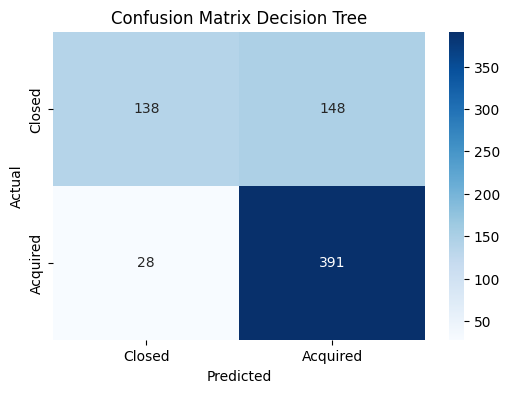

In [711]:
# Confusion matrix

cm_tree = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Decision Tree')
plt.show()

### K-Neighbors

In [712]:
# Model training

model = KNeighborsClassifier()

kneigh = GridSearchCV(estimator=model, param_grid={
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}, cv=5, scoring='roc_auc').fit(x_train, y_train)

In [713]:
# Model evaluation

y_pred = kneigh.predict(x_test)
y_proba = kneigh.predict_proba(x_test)[:, 1]

In [714]:
# Accuracy and AUC

accuracy_k = accuracy_score(y_test, y_pred)
auc_k = roc_auc_score(y_test, y_proba)
precision_k = classification_report(y_test, y_pred, output_dict=True)['True']['precision']
recall_k = classification_report(y_test, y_pred, output_dict=True)['True']['recall']

print(f"Accuracy: {accuracy_k:.4f}")
print(f"AUC: {auc_k:.4f}")
print(f"Precision: {precision_k:.4f}")
print(f"Recall: {recall_k:.4f}")

Accuracy: 0.7418
AUC: 0.7726
Precision: 0.7404
Recall: 0.8711


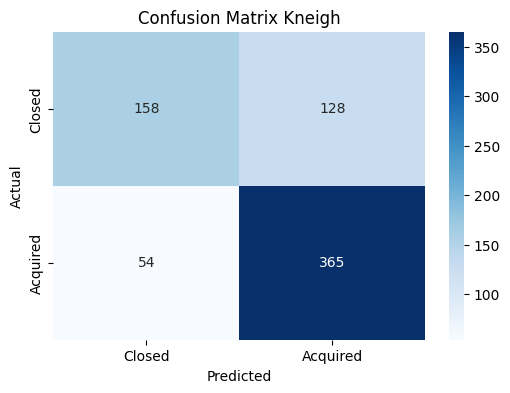

In [715]:
# Confusion matrix

cm_k = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_k, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Kneigh')
plt.show()

### Random forest

In [716]:
# Model training random forest

model = RandomForestClassifier()

model_rf = GridSearchCV(estimator=model, param_grid={
    'n_estimators': [25,50,100,200],
    'max_depth': range(1,10)
}, cv=5, scoring='roc_auc').fit(x_train, y_train)

In [717]:
# Model evaluation

y_pred = model_rf.predict(x_test)
y_proba = model_rf.predict_proba(x_test)[:, 1]

In [718]:
# Accuracy and AUC

accuracy_rf = accuracy_score(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_proba)
precision_rf = classification_report(y_test, y_pred, output_dict=True)['True']['precision']
recall_rf = classification_report(y_test, y_pred, output_dict=True)['True']['recall']

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")

Accuracy: 0.7617
AUC: 0.7981
Precision: 0.7525
Recall: 0.8926


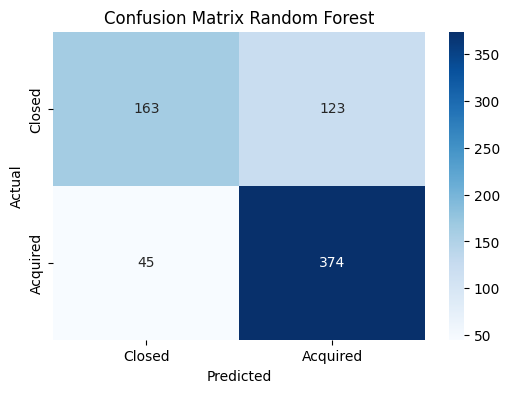

In [719]:
# Confusion matrix

cm_rf = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Random Forest')
plt.show()

### Boosting

In [720]:
# Model training

model = GradientBoostingClassifier()

model_gb = GridSearchCV(estimator=model, param_grid={
    'n_estimators': [25,50,100,200],
    'max_depth': range(1,10)
}, cv=5, scoring='roc_auc').fit(x_train, y_train)

In [721]:
# Model evaluation

y_pred = model_gb.predict(x_test)
y_proba = model_gb.predict_proba(x_test)[:, 1]

In [722]:
# Accuracy and AUC

accuracy_gb = accuracy_score(y_test, y_pred)
auc_gb = roc_auc_score(y_test, y_proba)
precision_gb = classification_report(y_test, y_pred, output_dict=True)['True']['precision']
recall_gb = classification_report(y_test, y_pred, output_dict=True)['True']['recall']

print(f"Accuracy: {accuracy_gb:.4f}")
print(f"AUC: {auc_gb:.4f}")
print(f"Precision: {precision_gb:.4f}")
print(f"Recall: {recall_gb:.4f}")

Accuracy: 0.7674
AUC: 0.8011
Precision: 0.7607
Recall: 0.8878


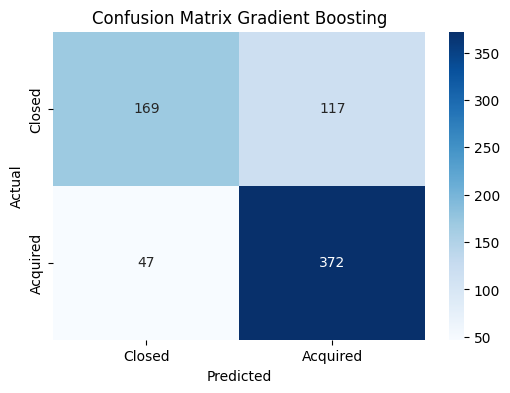

In [723]:
# Confusion matrix

cm_gb = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix Gradient Boosting')
plt.show()

### Conclusions

In [724]:
# Summary table of the models performance

b_models_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'K-Neighbors', 'Random Forest', 'Gradient Boosting'],
    'AUC': [auc_tree, auc_k, auc_rf, auc_gb],
    'Accuracy': [accuracy_tree, accuracy_k, accuracy_rf, accuracy_gb],
    'Precision':[precision_tree, precision_k, precision_rf, precision_gb],
    'Recall':[recall_tree, recall_k, recall_rf, recall_gb]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

b_models_summary

,Model,AUC,Accuracy,Precision,Recall
0,Gradient Boosting,0.801125,0.767376,0.760736,0.887828
1,Random Forest,0.798071,0.761702,0.752515,0.892601
2,Decision Tree,0.776879,0.750355,0.725417,0.933174
3,K-Neighbors,0.772631,0.741844,0.740365,0.871122


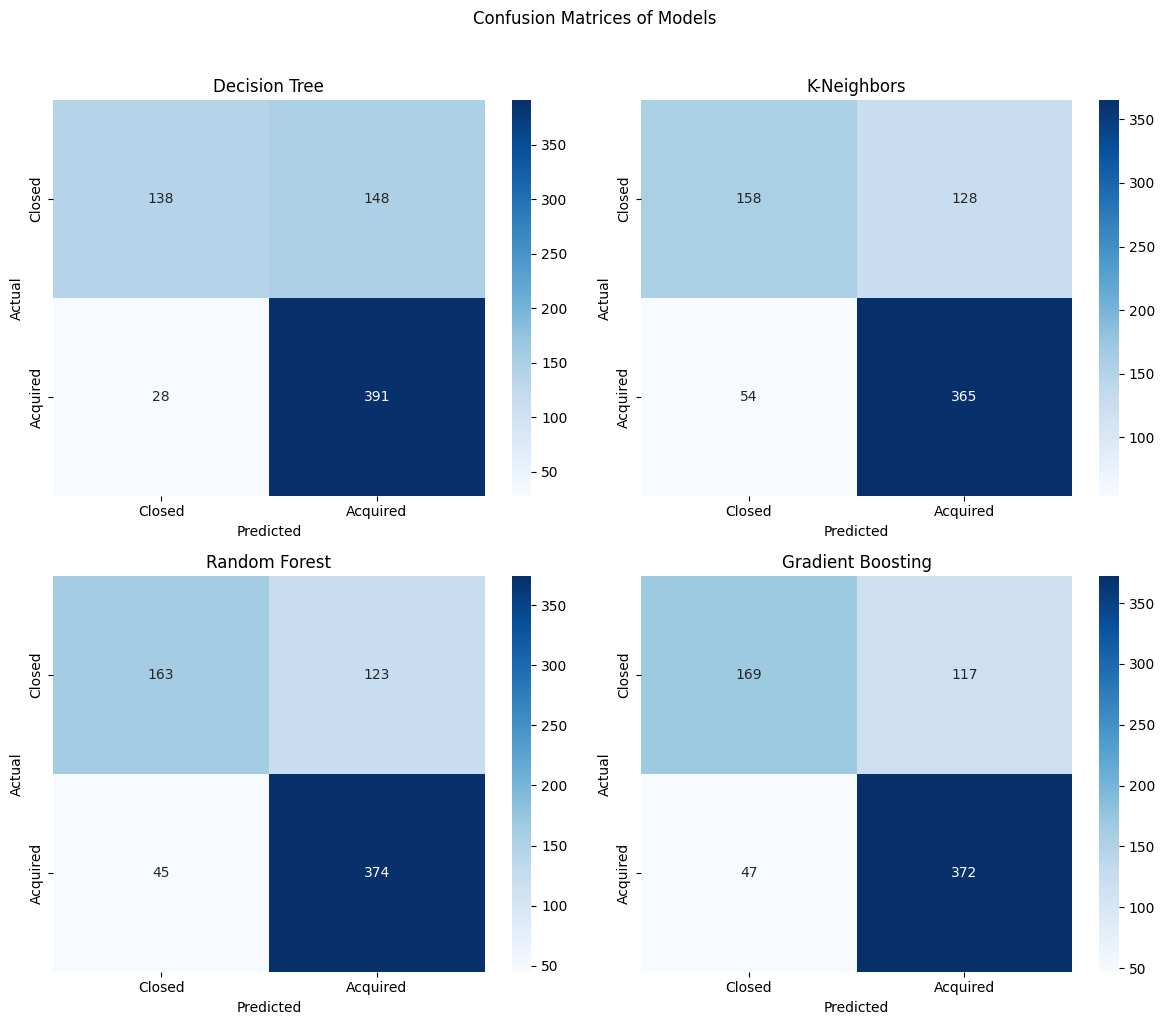

In [725]:
# Visualization of confusion matrices

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'], ax=axes[0, 0])
axes[0, 0].set_title('Decision Tree')
sns.heatmap(cm_k, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'], ax=axes[0, 1])
axes[0, 1].set_title('K-Neighbors')
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'], ax=axes[1, 0])
axes[1, 0].set_title('Random Forest')
sns.heatmap(cm_gb, annot=True, fmt='d', cmap='Blues', xticklabels=['Closed', 'Acquired'], yticklabels=['Closed', 'Acquired'], ax=axes[1, 1])
axes[1, 1].set_title('Gradient Boosting')
for ax in axes.flatten():
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
plt.suptitle('Confusion Matrices of Models', y=1.02)
plt.tight_layout()
plt.show()

We pick the Gradient boosting.

Decision is based on the following criteria:

- AUC as priority value considering the skewed distribution of target variable
- Precision over recall, higher cost in investing in a closed start-up rather than missing one acquired.

The boosting and random forest behaved similarly in terms of AUC and accuracy, still the GB scored better in precision, while random forest in recall.

In a case of different loss-avversion strategy, we might also suggest the usage of the random forest instead.

In general is worth observing that a potential common bias for all models is false positive, which can be explained by the lower representation of closed start-ups in the dataset.

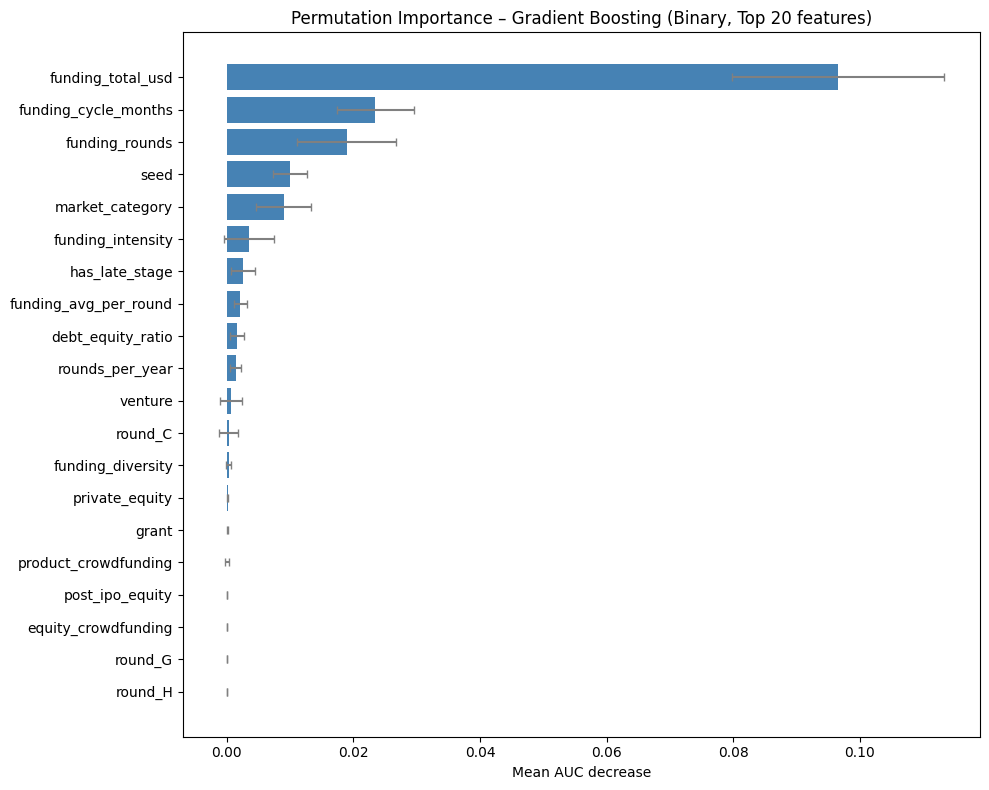

In [ ]:
# Permutation importance on the best binary model (Gradient Boosting) scored on AUC

x_bin = df_bclass.drop(columns='status')
y_bin = df_bclass['status']

x_train_bin, x_test_bin, y_train_bin, y_test_bin = train_test_split(
    x_bin, y_bin, test_size=0.2, random_state=42, stratify=y_bin
)
x_train_bin['market_category'] = encoder.transform(x_train_bin[['market_category']]).ravel()
x_test_bin['market_category'] = encoder.transform(x_test_bin[['market_category']]).ravel()

perm_imp_bin = permutation_importance(
    model_gb, x_test_bin, y_test_bin,
    scoring='roc_auc',
    n_repeats=10,
    random_state=42
)

perm_df_bin = pd.DataFrame({
    'Feature': x_test_bin.columns,
    'Importance Mean': perm_imp_bin.importances_mean,
    'Importance Std': perm_imp_bin.importances_std
}).sort_values('Importance Mean', ascending=False).reset_index(drop=True)

# Plot top 20 features
top_n = 20
plot_df_bin = perm_df_bin.head(top_n).sort_values('Importance Mean', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df_bin['Feature'], plot_df_bin['Importance Mean'],
         xerr=plot_df_bin['Importance Std'], color='steelblue', ecolor='gray', capsize=3)
plt.xlabel('Mean AUC decrease')
plt.title(f'Permutation Importance – Gradient Boosting (Binary, Top {top_n} features)')
plt.tight_layout()
plt.show()

The features importance analysis is coherent with what we would expect:

- Main drivers are the total financing volume and length of the financing operation
- Lower importance for less-represented financing forms

It's curious to note that, for at least the selected dataset, the most common financing form (Venture) isn't the main driver of the predictor's AUC.

In [733]:
# Training the best model on the entire dataset

x_bin_enc = x_bin.copy()
x_bin_enc['market_category'] = encoder.transform(x_bin_enc[['market_category']]).ravel()

model_parameters = model_gb.best_params_
best_model = GradientBoostingClassifier(**model_parameters, random_state=42)
best_model.fit(x_bin_enc, y_bin)


,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",50
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, `

In [735]:
# Exporting the best model and encoder

with open(repo_root / "Models" / "start_ups_success_predictor.pkl", "wb") as f:
    pck.dump(best_model, f)

with open(repo_root / "Models" / "market_category_encoder.pkl", "wb") as f:
    pck.dump(encoder, f)

## Multiclass classification: Start-up financing size

### Variables fine-tuning

We aim to bracket the funding total amount into 3 categories for prediction:

- seed ( < $1M)
- early ( $1M - $20M)
- growth (> $20M)

We observe the distribution and then adjust features calculated on the basis of "total_financing" to avoid leakage.

In [681]:
# Copying into a new dataframe

df_mclass = df_filtered.copy()

In [682]:
# Bracketing the dataset based on funding total

bins = [[0, 1e6, 2e7, np.inf]]
labels = ['seed', 'early', 'growth']

df_mclass['funding_bracket'] = pd.cut(df_mclass['funding_total_usd'], bins=bins[0], labels=labels, include_lowest=True)
df_mclass['funding_bracket'].value_counts(normalize=True).sort_values(ascending=False)

funding_bracket
seed      0.404616
early     0.397666
growth    0.197717
Name: proportion, dtype: float64

In [ ]:
# Transforming features expressed in $ to boolean in order to avoid data leakage

amount_cols = ['seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note', 
               'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity', 
               'post_ipo_debt', 'secondary_market', 'product_crowdfunding',
               'round_A', 'round_B', 'round_C', 'round_D', 'round_E', 'round_F', 'round_G', 'round_H']

df_mclass[amount_cols] = (df_mclass[amount_cols] > 0).astype(int)

In [684]:
# Dropping features expressed in $ to avoid data leakage

features_to_drop = ['funding_total_usd','funding_avg_per_round', 'funding_intensity', 'institutional_share','has_early_stage','has_late_stage','post_ipo_presence']
df_mclass = df_mclass.drop(columns=features_to_drop)

The distribution of the target variable is concentrated in the first 2 categories with an equal 40% share each.

The encoding strategy we opt is for a one-hot encoding for both market "category" and "status", while we decide to use a separate mapping and not an ordinal encoder for the target variable in order to keep the logical order of the 3 classes.

In [686]:
# Splitting the dataset into features and target

x = df_mclass.drop(columns='funding_bracket')
y = df_mclass['funding_bracket']

In [ ]:
# Encoding status and market category

x = pd.get_dummies(x, columns=['market_category', 'status'], drop_first=True)

# Encoding funding brackets

bracket_map = {'seed': 0, 'early': 1, 'growth': 2}
y = y.map(bracket_map)

In [ ]:
# Splitting train and test dataset (80% train, 20% test)

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

### Decision tree

In [594]:
# Model training

model = DecisionTreeClassifier(random_state=42)

decision_tree = GridSearchCV(estimator=model, param_grid={
    'max_depth': range(1,10),
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}, cv=5, scoring='roc_auc_ovr').fit(x_train, y_train)

In [595]:
# Model evaluation

y_pred = decision_tree.predict(x_test)
y_proba = decision_tree.predict_proba(x_test)

In [596]:
# Model performance metrics

accuracy_tree = accuracy_score(y_test, y_pred)
auc_tree = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
report_tree = classification_report(y_test, y_pred, output_dict=True)
precision_tree = report_tree['macro avg']['precision']
recall_tree = report_tree['macro avg']['recall']

print(f"Accuracy: {accuracy_tree:.4f}")
print(f"AUC: {auc_tree:.4f}")
print(f"Precision: {precision_tree:.4f}")
print(f"Recall: {recall_tree:.4f}")

Accuracy: 0.7441
AUC: 0.8903
Precision: 0.7501
Recall: 0.7353


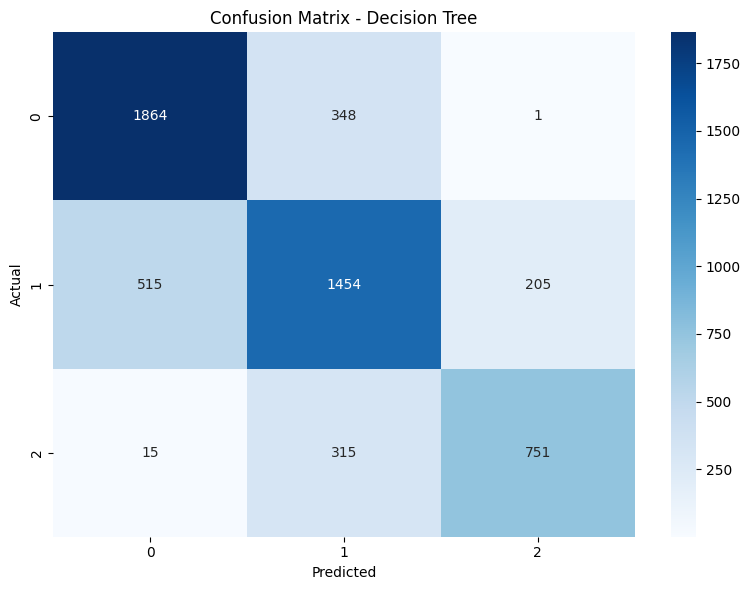

In [600]:
# Confusion matrix

labels = decision_tree.classes_
cm_tree = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Decision Tree')
plt.tight_layout()
plt.show()

### K-Neighbors

In [601]:
# Model training

model = KNeighborsClassifier()

kneigh = GridSearchCV(estimator=model, param_grid={
    'n_neighbors': range(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}, cv=5, scoring='roc_auc_ovr').fit(x_train, y_train)

In [602]:
# Model evaluation

y_pred = kneigh.predict(x_test)
y_proba = kneigh.predict_proba(x_test)

In [603]:
# Model performance metrics

accuracy_k = accuracy_score(y_test, y_pred)
auc_k = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
report_k = classification_report(y_test, y_pred, output_dict=True)
precision_k = report_k['macro avg']['precision']
recall_k = report_k['macro avg']['recall']

print(f"Accuracy: {accuracy_k:.4f}")
print(f"AUC: {auc_k:.4f}")
print(f"Precision: {precision_k:.4f}")
print(f"Recall: {recall_k:.4f}")

Accuracy: 0.7215
AUC: 0.8707
Precision: 0.7453
Recall: 0.6899


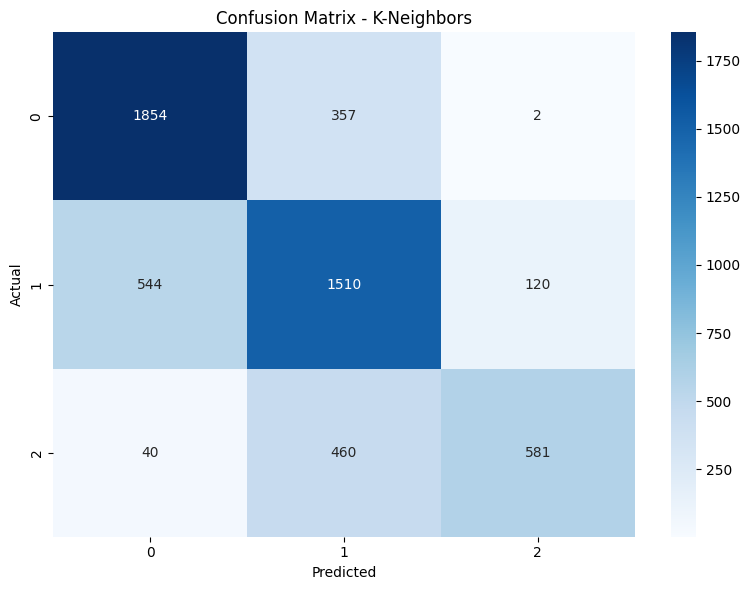

In [604]:
# Confusion matrix

labels = kneigh.classes_
cm_k = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_k, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - K-Neighbors')
plt.tight_layout()
plt.show()

### Random forest

In [605]:
# Model training

model = RandomForestClassifier()

model_rf = GridSearchCV(estimator=model, param_grid={
    'n_estimators': [25,50,100,200],
    'max_depth': range(1,10)
}, cv=5, scoring='roc_auc_ovr').fit(x_train, y_train)

In [606]:
# Model evaluation

y_pred = model_rf.predict(x_test)
y_proba = model_rf.predict_proba(x_test)

In [607]:
# Model performance metrics

accuracy_rf = accuracy_score(y_test, y_pred)
auc_rf = roc_auc_score(y_test, y_proba, multi_class='ovr', average='macro')
report_rf = classification_report(y_test, y_pred, output_dict=True)
precision_rf = report_rf['macro avg']['precision']
recall_rf = report_rf['macro avg']['recall']

print(f"Accuracy: {accuracy_rf:.4f}")
print(f"AUC: {auc_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall: {recall_rf:.4f}")

Accuracy: 0.7518
AUC: 0.8948
Precision: 0.7655
Recall: 0.7338


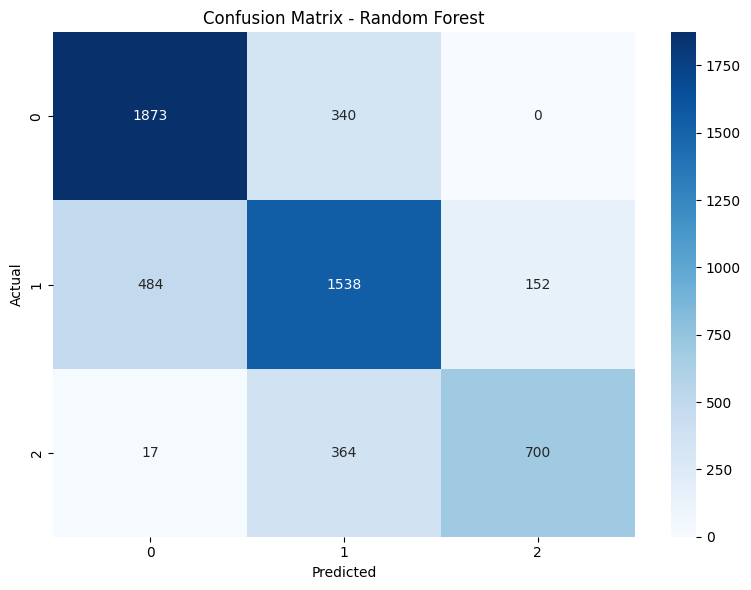

In [608]:
# Confusion matrix

labels = model_rf.classes_
cm_rf = confusion_matrix(y_test, y_pred, labels=labels)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Random Forest')
plt.tight_layout()
plt.show()

### Conclusions

In [692]:
# Summary table of the models performance

m_models_summary = pd.DataFrame({
    'Model': ['Decision Tree', 'K-Neighbors', 'Random Forest'],
    'AUC': [auc_tree, auc_k, auc_rf],
    'Accuracy': [accuracy_tree, accuracy_k, accuracy_rf],
    'Precision':[precision_tree, precision_k, precision_rf],
    'Recall':[recall_tree, recall_k, recall_rf]
}).sort_values('AUC', ascending=False).reset_index(drop=True)

m_models_summary

,Model,AUC,Accuracy,Precision,Recall
0,Random Forest,0.894806,0.751829,0.765518,0.733788
1,Decision Tree,0.890300,0.744148,0.750059,0.735279
2,K-Neighbors,0.870699,0.721470,0.745274,0.689938


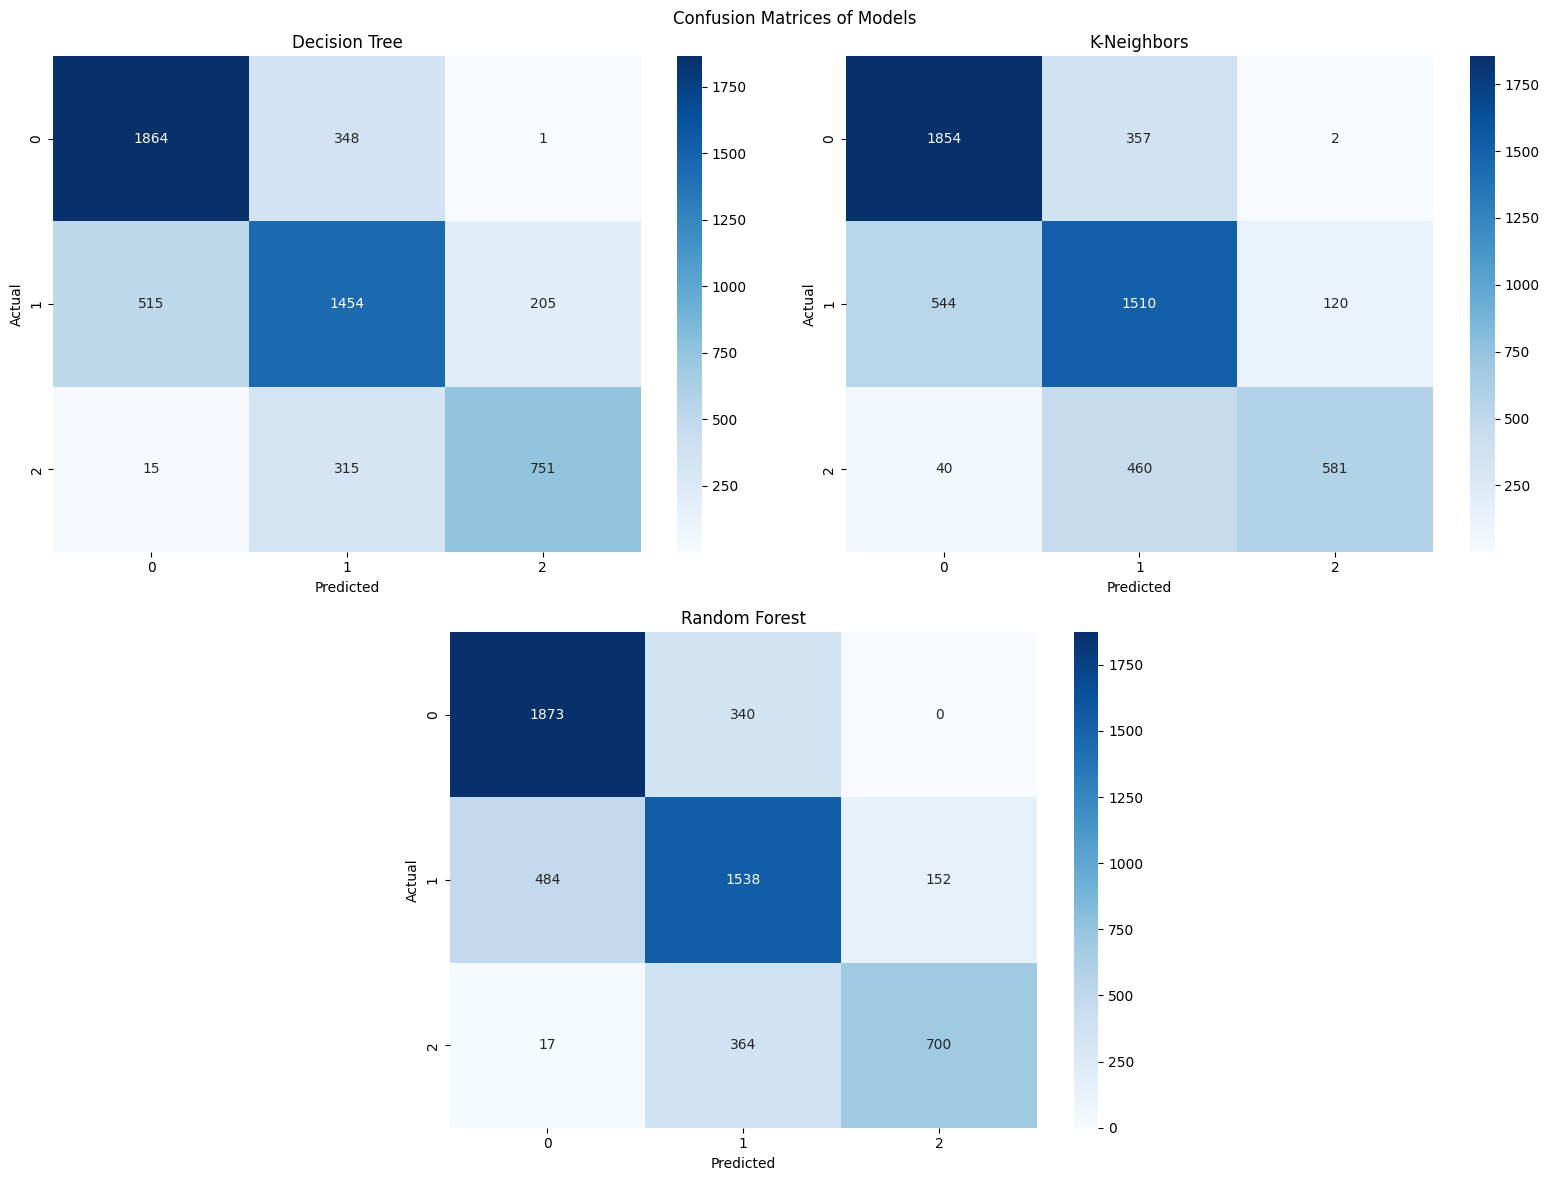

In [694]:
# Visualization of confusion matrices

from matplotlib.gridspec import GridSpec

labels = decision_tree.classes_
fig = plt.figure(figsize=(16, 12))
gs = GridSpec(2, 4, figure=fig)

ax1 = fig.add_subplot(gs[0, 0:2])
ax2 = fig.add_subplot(gs[0, 2:4])
ax3 = fig.add_subplot(gs[1, 1:3])

sns.heatmap(cm_tree, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax1)
ax1.set_title('Decision Tree')
ax1.set_xlabel('Predicted')
ax1.set_ylabel('Actual')

sns.heatmap(cm_k, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax2)
ax2.set_title('K-Neighbors')
ax2.set_xlabel('Predicted')
ax2.set_ylabel('Actual')

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels, ax=ax3)
ax3.set_title('Random Forest')
ax3.set_xlabel('Predicted')
ax3.set_ylabel('Actual')

plt.suptitle('Confusion Matrices of Models')
plt.tight_layout()
plt.show()

We have excluded the gradient booster classifier from this classification since the hyperparameters optimization was taking significantly longer tha other model.

In this case we evaluate the models performance with the following criteria:

- AUC over accuracy, considering the unbalanced representation growth category
- Precision over recall, considering the prospect of an investment entity, we value more minimizing misinterpreting an higher valued start-ups

The random forest is the highest scorer in both categories in this classification task.

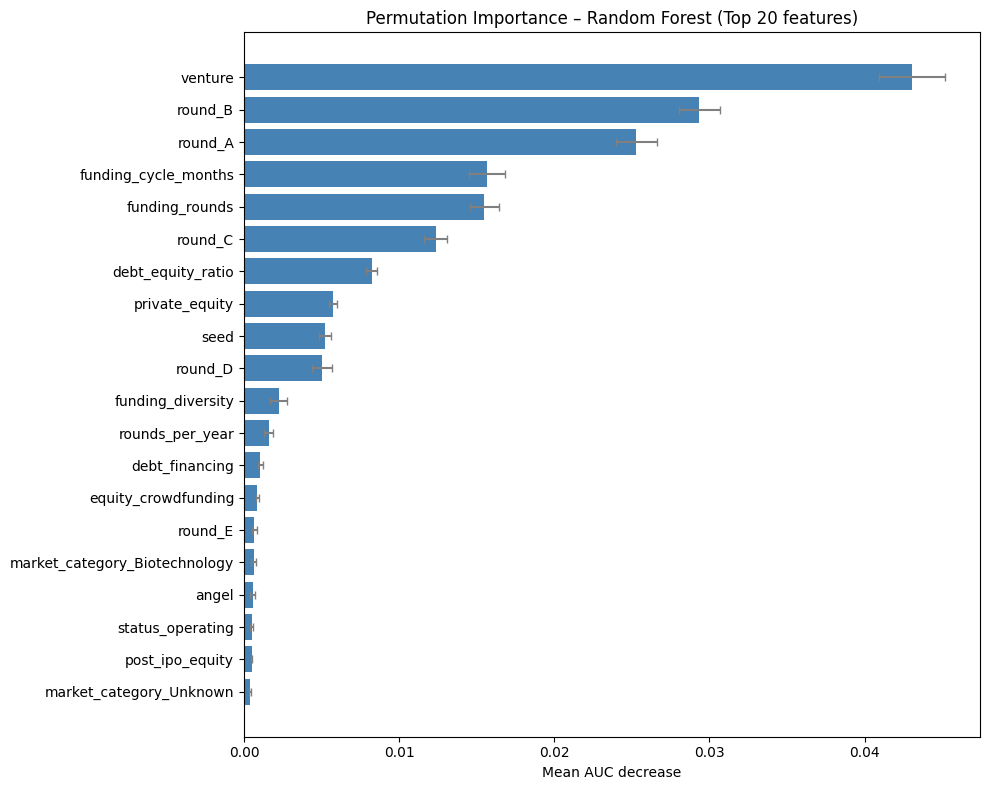

In [695]:

# Permutation importance on the best model (Random Forest) scored on AUC OVR macro

perm_imp = permutation_importance(
    model_rf, x_test, y_test,
    scoring='roc_auc_ovr',
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    'Feature': x_test.columns,
    'Importance Mean': perm_imp.importances_mean,
    'Importance Std': perm_imp.importances_std
}).sort_values('Importance Mean', ascending=False).reset_index(drop=True)

# Plot top 20 features
top_n = 20
plot_df = perm_df.head(top_n).sort_values('Importance Mean', ascending=True)

plt.figure(figsize=(10, 8))
plt.barh(plot_df['Feature'], plot_df['Importance Mean'],
         xerr=plot_df['Importance Std'], color='steelblue', ecolor='gray', capsize=3)
plt.xlabel('Mean AUC decrease')
plt.title(f'Permutation Importance – Random Forest (Top {top_n} features)')
plt.tight_layout()
plt.show()

The multiclass prediction task share with the binary features importance like the funding cycle lenght and rounds.

It's interesting to see how the presence of venture capitals gains importance in determining the financing size, as well as round A and B investments.

The results are in general coherent with the expectations of the model and we don't highlight any leakage or anomaly in the feature selection and engineering.

In [698]:
# Training the best model on the entire dataset

model_parameters = model_rf.best_estimator_
best_estimator = model_parameters.get_params()['n_estimators']
max_depth = model_parameters.get_params()['max_depth']

best_model = RandomForestClassifier(n_estimators=best_estimator, max_depth=max_depth, random_state=42)
best_model.fit(x, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",9
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_

In [699]:
# Exporting the model

with open(repo_root / "Models" / "start_ups_investment_predictor.pkl", "wb") as f:
    pck.dump(best_model, f)

## Neural network

As last step we explore the usage of neural networks to improve the accuracy of the prediction models we just formulated. 

We'll explore different network architecture to try to optimize the model's accuracy.

### Binary classification

#### Variables fine-tuning

We decide to opt for a standard one-hot encoding strategy for neural netowrks since it increase number of features and probability to detect hidden patterns in the data.

Further operation we apply on the data:

- Transforming target variable to int
- Scaling the $ features to improve NN performance
- Computing class weights for target variable to tackle imbalance

In [736]:
# Recalling the previous dataset for binary classification

df_bclass.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
market_category,3523,20,Software & SaaS,758,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funding_total_usd,3523.0,NaN,NaN,NaN,25821718.659949,120421444.313187,1000.0,685675.0,5500000.0,24370000.0,5700000000.0
funding_rounds,3523.0,NaN,NaN,NaN,2.01107,1.356266,1.0,1.0,2.0,3.0,10.0
status,3523,2,True,2093,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seed,3523.0,NaN,NaN,NaN,230452.336645,774148.553688,0.0,0.0,0.0,50000.0,21000000.0
venture,3523.0,NaN,NaN,NaN,11704293.537326,28021013.741197,0.0,0.0,3000000.0,13000000.0,775000000.0
equity_crowdfunding,3523.0,NaN,NaN,NaN,2256.599489,101093.622496,0.0,0.0,0.0,0.0,5500000.0
undisclosed,3523.0,NaN,NaN,NaN,39541.518024,746260.101469,0.0,0.0,0.0,0.0,30000000.0
convertible_note,3523.0,NaN,NaN,NaN,10495.991768,251867.206217,0.0,0.0,0.0,0.0,13520145.0
debt_financing,3523.0,NaN,NaN,NaN,1082558.509793,17520406.195418,0.0,0.0,0.0,0.0,721644319.0


In [738]:
# Encoding the dataset

df_bclass_nn = df_bclass.copy()

# Convert boolean target to int (False=closed=0, True=acquired=1)
df_bclass_nn['status'] = df_bclass_nn['status'].astype(int)

# One-hot encode nominal categorical columns
nominal_cols = ['market_category']
df_bclass_nn = pd.get_dummies(df_bclass_nn, columns=nominal_cols)

# Convert remaining boolean columns to int
bool_cols = df_bclass_nn.select_dtypes(include='bool').columns
df_bclass_nn[bool_cols] = df_bclass_nn[bool_cols].astype(int)

In [739]:
# Split the dataset into features and target

x = df_bclass_nn.drop(columns='status')
y = df_bclass_nn['status']

In [740]:
# Split into train and test dataset

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

# Scaling the features with StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

# Computing class weights to handle binary class imbalance (acquired >> closed)
from sklearn.utils.class_weight import compute_class_weight

bclass_labels = np.array([0, 1])
bclass_weights = compute_class_weight('balanced', classes=bclass_labels, y=y_train)
bclass_weight_dict = dict(enumerate(bclass_weights))

print("Binary class weights:", bclass_weight_dict)


Binary class weights: {0: np.float64(1.2316433566433567), 1: np.float64(0.8416965352449224)}


#### Single-layer network

In [741]:
# Creating the model

input_dim = x_train.shape[1]
num_classes = len(y_train.unique())

model_l1 = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(1, activation='sigmoid')
])

model_l1.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', keras.metrics.AUC(name='auc')])


In [742]:
# Training the model

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_l1.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test),
             callbacks=[early_stop], class_weight=bclass_weight_dict)


Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.5447 - auc: 0.5762 - loss: 0.7412 - val_accuracy: 0.5674 - val_auc: 0.6145 - val_loss: 0.7253
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6008 - auc: 0.6557 - loss: 0.6811 - val_accuracy: 0.6099 - val_auc: 0.6757 - val_loss: 0.6856
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6256 - auc: 0.6979 - loss: 0.6507 - val_accuracy: 0.6355 - val_auc: 0.7100 - val_loss: 0.6624
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6458 - auc: 0.7200 - loss: 0.6322 - val_accuracy: 0.6553 - val_auc: 0.7287 - val_loss: 0.6485
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6551 - auc: 0.7350 - loss: 0.6197 - val_accuracy: 0.6582 - val_auc: 0.7407 - val_loss: 0.6383
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6678 - auc: 0.7452 - loss: 0.6109 - val_accuracy: 0.6610 - val_auc: 0.7491 - val_loss: 0.6312
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/

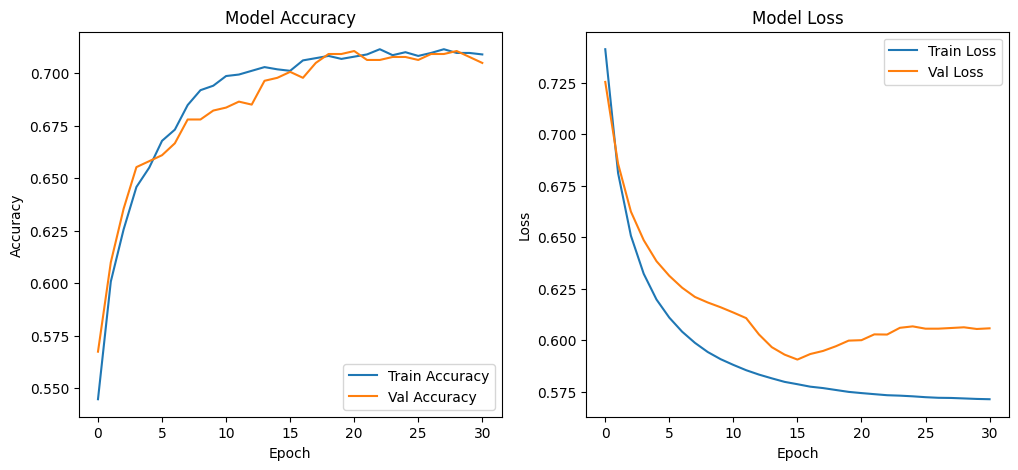

In [743]:
# Visualizing training history

def plot_history(history):
    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.plot(history['accuracy'], label='Train Accuracy')
    plt.plot(history['val_accuracy'], label='Val Accuracy')
    plt.title('Model Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.subplot(1, 2, 2)
    plt.plot(history['loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title('Model Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

plot_history(model_l1.history.history)

In [745]:
# Evaluating the model on the test set

test_loss, test_accuracy_l1, test_auc_l1 = model_l1.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy_l1:.4f}")
print(f"Test AUC: {test_auc_l1:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7007 - auc: 0.7674 - loss: 0.5905
Test Accuracy: 0.7007
Test AUC: 0.7674


#### 2-layers network

In [746]:
# Creating the model

input_dim = x_train.shape[1]
num_classes = len(y_train.unique())

model_l2 = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(32, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(16, activation='relu',
                       kernel_regularizer=keras.regularizers.l2(0.001)),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(1, activation='sigmoid')
])

model_l2.compile(optimizer='adam', loss='binary_crossentropy',
                 metrics=['accuracy', keras.metrics.AUC(name='auc')])


In [747]:
# Training the model

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model_l2.fit(x_train, y_train, epochs=100, validation_data=(x_test, y_test),
             callbacks=[early_stop], class_weight=bclass_weight_dict)


Epoch 1/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - accuracy: 0.5600 - auc: 0.5666 - loss: 0.8752 - val_accuracy: 0.6794 - val_auc: 0.7181 - val_loss: 0.7631
Epoch 2/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6214 - auc: 0.6691 - loss: 0.7283 - val_accuracy: 0.7092 - val_auc: 0.7469 - val_loss: 0.7169
Epoch 3/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6419 - auc: 0.7018 - loss: 0.6938 - val_accuracy: 0.7220 - val_auc: 0.7598 - val_loss: 0.6897
Epoch 4/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6732 - auc: 0.7284 - loss: 0.6648 - val_accuracy: 0.7291 - val_auc: 0.7705 - val_loss: 0.6633
Epoch 5/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6771 - auc: 0.7323 - loss: 0.6594 - val_accuracy: 0.7291 - val_auc: 0.7734 - val_loss: 0.6516
Epoch 6/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6906 - auc: 0.7468 - loss: 0.6427 - val_accuracy: 0.7291 - val_auc: 0.7753 - val_loss: 0.6428
Epoch 7/100
89/89 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms

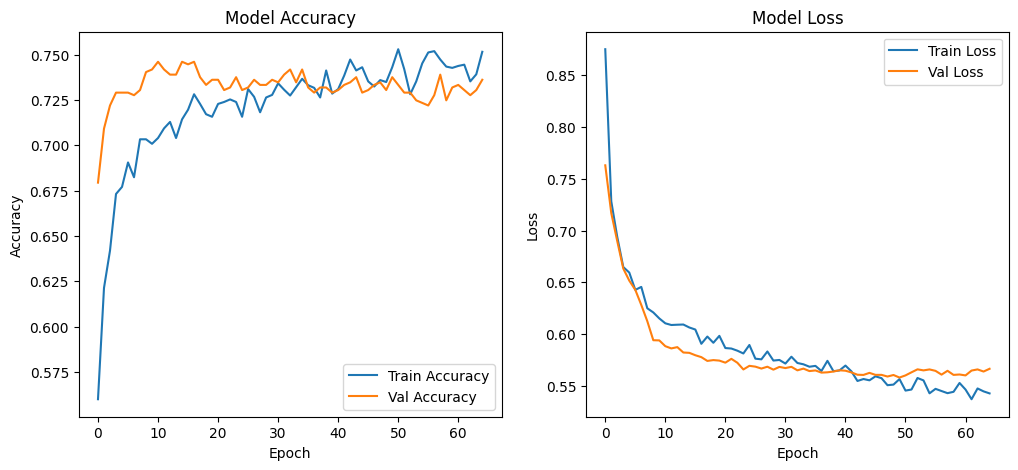

In [749]:
# Visualizing training history

plot_history(model_l2.history.history)

In [750]:
# Evaluating the model on the test set

test_loss, test_accuracy_l2, test_auc_l2 = model_l2.evaluate(x_test, y_test)
print(f"Test Accuracy: {test_accuracy_l2:.4f}")
print(f"Test AUC: {test_auc_l2:.4f}")

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7376 - auc: 0.7973 - loss: 0.5580
Test Accuracy: 0.7376
Test AUC: 0.7973


#### Conclusions

In [752]:
# Generating summary table of the models performance

nn_b_models_summary = pd.DataFrame({
    'Model': ['Logistic Regression (L1)', 'Deep Neural Network (L2)'],
    'Test Accuracy': [test_accuracy_l1, test_accuracy_l2],
    'Test AUC': [test_auc_l1, test_auc_l2]
}).sort_values('Test AUC', ascending=False).reset_index(drop=True)

nn_b_models_summary

,Model,Test Accuracy,Test AUC
0,Deep Neural Network (L2),0.737589,0.797282
1,Logistic Regression (L1),0.700709,0.767412


We haven't gone deeper into more complex architecture as we have noticed a decrease in the Test Accuracy and AUC already with 3 layers networks.

If we compare the performance of the best standard machine learning models in the same classification task:

Gradient Boosting	
Accuracy: 0.767376
Auc: 0.801125

The standard machine learning models outperforms deep learning architecture, even if the AUC is similar, the difference in accuracy in significant. (~3%).

### Multiclass classification

#### Variables fine-tuning

In [763]:
# Recalling the previous dataset for multi-classification

df_mclass.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
market_category,27337,20,Software & SaaS,5279,NaN,NaN,NaN,NaN,NaN,NaN,NaN
funding_rounds,27337.0,NaN,NaN,NaN,1.976771,1.473553,1.0,1.0,1.0,2.0,18.0
status,27337,3,operating,23814,NaN,NaN,NaN,NaN,NaN,NaN,NaN
seed,27337.0,NaN,NaN,NaN,0.389911,0.487739,0.0,0.0,0.0,1.0,1.0
venture,27337.0,NaN,NaN,NaN,0.552658,0.497229,0.0,0.0,1.0,1.0,1.0
equity_crowdfunding,27337.0,NaN,NaN,NaN,0.015839,0.124856,0.0,0.0,0.0,0.0,1.0
undisclosed,27337.0,NaN,NaN,NaN,0.019241,0.137375,0.0,0.0,0.0,0.0,1.0
convertible_note,27337.0,NaN,NaN,NaN,0.016278,0.126546,0.0,0.0,0.0,0.0,1.0
debt_financing,27337.0,NaN,NaN,NaN,0.104218,0.305548,0.0,0.0,0.0,0.0,1.0
angel,27337.0,NaN,NaN,NaN,0.094963,0.293169,0.0,0.0,0.0,0.0,1.0


In [764]:
# Copying the multi-class dataset for neural network modeling

df_mclass_nn = df_mclass.copy()

# Encode the target variable (funding_bracket)

map = {'seed': 0, 'early': 1, 'growth': 2}
df_mclass_nn['funding_bracket'] = df_mclass_nn['funding_bracket'].map(map)
df_mclass_nn['funding_bracket'] = df_mclass_nn['funding_bracket'].astype(int)

# One-hot encode nominal categorical input columns
df_mclass_nn = pd.get_dummies(df_mclass_nn, columns=['market_category', 'status'], drop_first=True)

# Convert remaining boolean columns to int
bool_cols = df_mclass_nn.select_dtypes(include='bool').columns
df_mclass_nn[bool_cols] = df_mclass_nn[bool_cols].astype(int)

df_mclass_nn.info()

<class 'pandas.DataFrame'>
RangeIndex: 27337 entries, 0 to 27336
Data columns (total 48 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   funding_rounds                             27337 non-null  float64
 1   seed                                       27337 non-null  int64  
 2   venture                                    27337 non-null  int64  
 3   equity_crowdfunding                        27337 non-null  int64  
 4   undisclosed                                27337 non-null  int64  
 5   convertible_note                           27337 non-null  int64  
 6   debt_financing                             27337 non-null  int64  
 7   angel                                      27337 non-null  int64  
 8   grant                                      27337 non-null  int64  
 9   private_equity                             27337 non-null  int64  
 10  post_ipo_equity                  

In [765]:
# Split the dataset into features and target

x = df_mclass_nn.drop(columns='funding_bracket')
y = df_mclass_nn['funding_bracket']

In [766]:
# Split the dataset into train and test

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

In [ ]:
# Computing class weights to handle imbalanced target classes

class_labels = np.unique(y_train)
weights = compute_class_weight('balanced', classes=class_labels, y=y_train)
class_weight_dict = dict(enumerate(weights))

# Per-sample weight array for training set (JAX-compatible alternative to class_weight)
sample_weights_train = np.array([class_weight_dict[c] for c in y_train])

print("Class weights:", class_weight_dict)

Class weights: {0: np.float64(0.8238773357444243), 1: np.float64(0.8381817484956499), 2: np.float64(1.6858618563058896)}


#### Single-layer network

In [768]:
# Generating the neural network model

input_dim = x_train.shape[1]
num_classes = len(y_train.unique())

sl_model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(num_classes, activation='softmax')
])

sl_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [769]:
# Training the sl model

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
sl_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test),
             callbacks=[early_stop], sample_weight=sample_weights_train)


Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6535 - loss: 1.1325 - val_accuracy: 0.7163 - val_loss: 1.1082
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7070 - loss: 0.9741 - val_accuracy: 0.7014 - val_loss: 1.1367
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7079 - loss: 1.0081 - val_accuracy: 0.6995 - val_loss: 0.8697
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7104 - loss: 0.9977 - val_accuracy: 0.7211 - val_loss: 1.0854
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7095 - loss: 0.9969 - val_accuracy: 0.7162 - val_loss: 1.0866
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7130 - loss: 0.9815 - val_accuracy: 0.6950 - val_loss: 1.1200
Epoch 7/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7166 - loss: 0.9465 - val_accuracy: 0.7034 - val_loss: 1.1094
Epoch 8/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7117 - loss: 0.9993 - val_accu

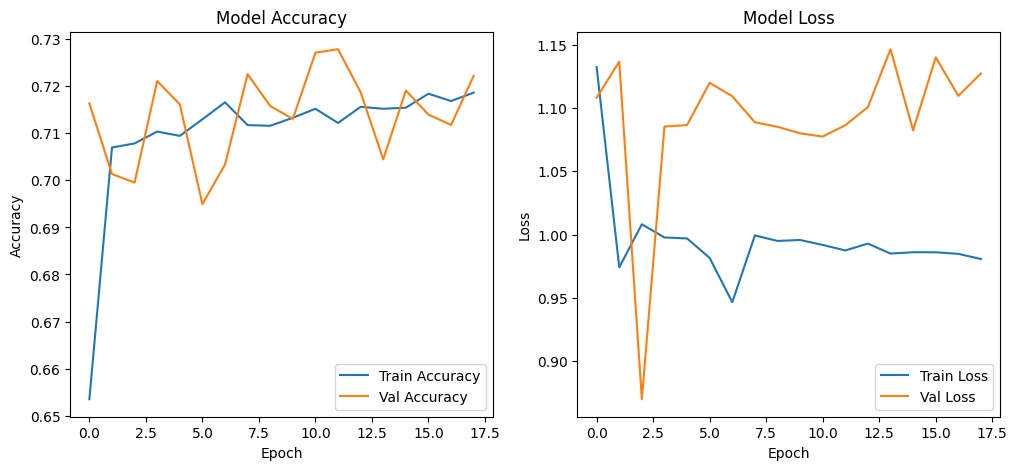

In [770]:
# Visualizing training history

history_sl = sl_model.history.history
plot_history(history_sl)

In [771]:
# Evaluating the model on the test set

y_proba_sl = sl_model.predict(x_test)
auc_sl = roc_auc_score(y_test, y_proba_sl, multi_class='ovr', average='macro')
acc_sl = accuracy_score(y_test, np.argmax(y_proba_sl, axis=1))

print(f"Test Accuracy: {acc_sl:.4f}")
print(f"Test AUC: {auc_sl:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 956us/step
Test Accuracy: 0.6995
Test AUC: 0.8728


#### 2-Layers network

In [772]:
# Generating the 2 hidden layers neural network model

input_dim = x_train.shape[1]
num_classes = len(y_train.unique())

l2_model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_classes, activation='softmax')
])

l2_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [773]:
# Training the 2 hidden layers

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
l2_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test),
             callbacks=[early_stop], sample_weight=sample_weights_train)


Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6184 - loss: 0.8316 - val_accuracy: 0.7087 - val_loss: 0.6812
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6891 - loss: 0.6832 - val_accuracy: 0.7195 - val_loss: 0.6494
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6986 - loss: 0.6551 - val_accuracy: 0.6887 - val_loss: 0.6701
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7071 - loss: 0.6345 - val_accuracy: 0.7149 - val_loss: 0.6361
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7109 - loss: 0.6297 - val_accuracy: 0.7341 - val_loss: 0.6098
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7106 - loss: 0.6256 - val_accuracy: 0.7292 - val_loss: 0.6081
Epoch 7/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7108 - loss: 0.6254 - val_accuracy: 0.7282 - val_loss: 0.6195
Epoch 8/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7106 - loss: 0.6237 - val_accu

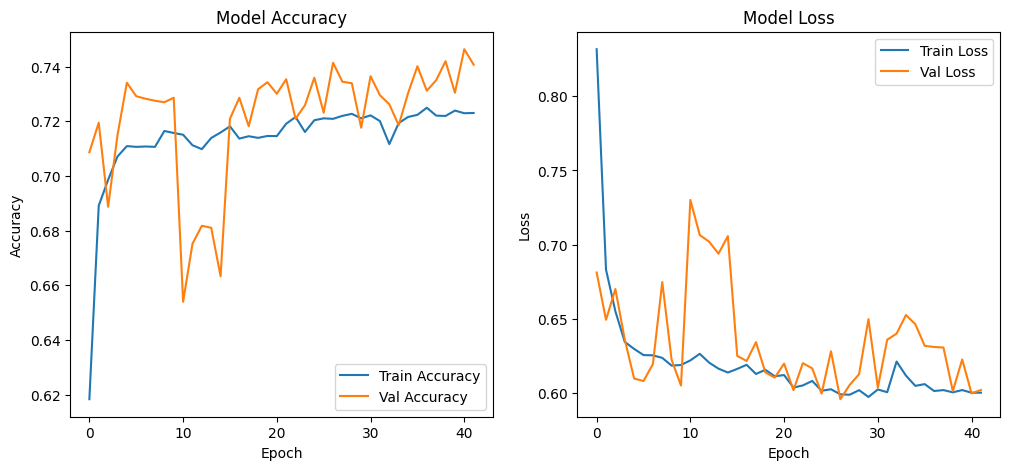

In [774]:
# Visualizing training history

history_l2 = l2_model.history.history
plot_history(history_l2)

In [775]:
y_proba_l2 = l2_model.predict(x_test)
auc_l2 = roc_auc_score(y_test, y_proba_l2, multi_class='ovr', average='macro')
acc_l2 = accuracy_score(y_test, np.argmax(y_proba_l2, axis=1))

print(f"Test Accuracy: {acc_l2:.4f}")
print(f"Test AUC: {auc_l2:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
Test Accuracy: 0.7414
Test AUC: 0.8839


#### 3-Layers network

In [776]:
# Generating the 3 hidden layers neural network model

input_dim = x_train.shape[1]
num_classes = len(y_train.unique())

l3_model = keras.Sequential([
    keras.layers.Input(shape=(input_dim,)),
    keras.layers.Dense(96, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.BatchNormalization(),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(num_classes, activation='softmax')
])

l3_model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


In [777]:
# Training the 3 hidden layers

early_stop = keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
l3_model.fit(x_train, y_train, epochs=100, batch_size=32, validation_data=(x_test, y_test),
             callbacks=[early_stop], sample_weight=sample_weights_train)


Epoch 1/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.6456 - loss: 0.7803 - val_accuracy: 0.7251 - val_loss: 0.6538
Epoch 2/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6913 - loss: 0.6648 - val_accuracy: 0.7312 - val_loss: 0.6378
Epoch 3/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6940 - loss: 0.6510 - val_accuracy: 0.7098 - val_loss: 0.6527
Epoch 4/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7015 - loss: 0.6361 - val_accuracy: 0.7153 - val_loss: 0.6530
Epoch 5/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7106 - loss: 0.6266 - val_accuracy: 0.7242 - val_loss: 0.6557
Epoch 6/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7086 - loss: 0.6272 - val_accuracy: 0.7191 - val_loss: 0.6599
Epoch 7/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7109 - loss: 0.6229 - val_accuracy: 0.7270 - val_loss: 0.6323
Epoch 8/100
684/684 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.7176 - loss: 0.6142 - val_accu

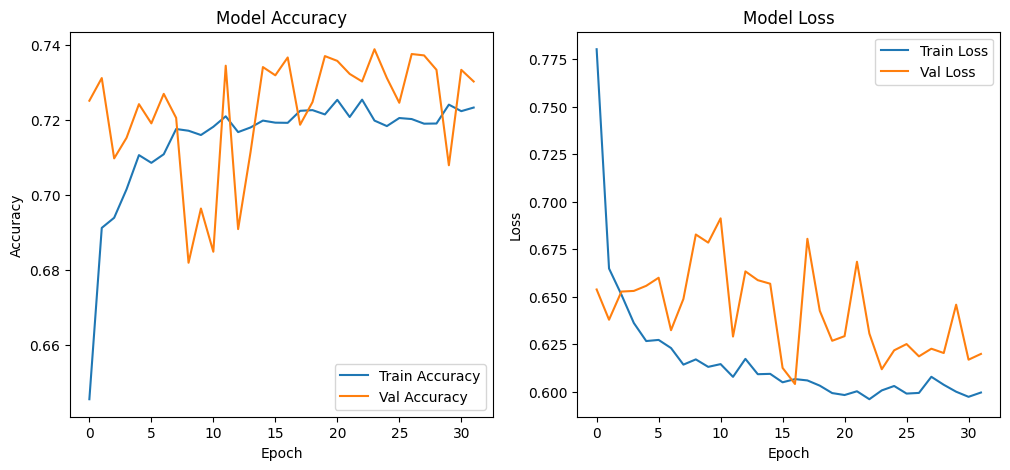

In [778]:
# Visualizing training history

history_l3 = l3_model.history.history
plot_history(history_l3)

In [779]:
# Evaluating the model on the test set

y_proba_l3 = l3_model.predict(x_test)
auc_l3 = roc_auc_score(y_test, y_proba_l3, multi_class='ovr', average='macro')
acc_l3 = accuracy_score(y_test, np.argmax(y_proba_l3, axis=1))

print(f"Test Accuracy: {acc_l3:.4f}")
print(f"Test AUC: {auc_l3:.4f}")

171/171 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Test Accuracy: 0.7366
Test AUC: 0.8820


#### Conclusions

In [781]:
# Generating summary table

nn_m_models_summary = pd.DataFrame({
        'Model': ['Single Hidden Layer', 'Two Hidden Layers', 'Three Hidden Layers'],
        'Test Accuracy': [acc_sl, acc_l2, acc_l3],
        'Test AUC': [auc_sl, auc_l2, auc_l3]
    }).sort_values('Test AUC', ascending=False).reset_index(drop=True)

nn_m_models_summary

,Model,Test Accuracy,Test AUC
0,Two Hidden Layers,0.741405,0.883894
1,Three Hidden Layers,0.736650,0.881975
2,Single Hidden Layer,0.699525,0.872807


Comparing the results of the best traditional machine learning model for the same classification task:

Random Forest	
AUC         0.894806
Accuracy	0.751829

Even if we haven't gone deeper in optimization of the neuronal network, we notice a similar pattern of the previous classification task.

Adding dense layers to the model isn't having a positive impact to the model's performance and overall, the difference in AUC and accuracy between NN and RF is of ~1% for both indicators (AUC and accuracy).

## Final Conclusions

#### 1. Key Takeaways

Data Preprocessing & Feature Engineering.

 The data has already being cleaned in a previous step for most common data cleaning tasks.
 Other significant preprocessing tasks involved:

- Encoding categorical variables with target encoding and standard hot-encoding strategies
- Filtered for start-up founded between 2000-2014 for training relevance
        
The features engineering has involved mainly the calculation of ratios and boolean features to try capturing significant signals affecting the predicitons (Debt ratio, late-stage, IPO etc.)

Unbalanced distribution handling

The dataset was naturally imbalanced (fewer "successful" exits than active/closed startups). The implementation of class weights during the training phase was critical to ensure the model didn't simply default to predicting the majority class, thereby improving the recall of potential "success" stories.

#### 2. Model selection and rationale

For both the Binary and Multiclass tasks, we have opted for Standard Machine Learning Models (Gradient Boosting and Random Forest) over Neural Networks.

                        AUC         Accuracy
        Binary          0.801125    0.767376
        Multiclass      0.894806    0.751829

Standard ensemble models achieved higher AUC and Accuracy scores across both tasks.

These models allow for better feature importance analysis, which is crucial for an investment fund to understand why a startup is predicted to be successful.

They reached higher performance with significantly less computational overhead and tuning compared to the Deep Learning architectures.

#### 3. Model limitations

#### 4. Reccomendations

Despite the models performance in both identifying start-up success and size of investment, the limitations highlighted previously limits the usage of the model for a initial screening.

The model should only be intended for a discrimination of the start-ups who presents a high probability of not being successful, allowing the team to focus on a more in-depth due diligence on a limited number of start-ups.

We also reccomend that the model is re-trained after 6-12 months of usage, in order to gather more relevant data of how the European start-ups and financial ecosystems function.